# Configure

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Packages
import requests
import os
import re
from os.path import join
from pathlib import Path
import yaml
from yaml.loader import SafeLoader
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import numpy as np
import rioxarray as rio
import xarray as xr

import unsafe.download as undown
import unsafe.files as unfile
import unsafe.unzip as ununzip
import unsafe.exp as unexp
import unsafe.ddfs as unddf
import unsafe.ensemble as unens

In [3]:
# Name the fips, statefips, stateabbr, and nation that
# we are using for this analysis
# We pass these in as a list even though the framework currently
# processes a single county so that it can facilitate that
# expansion in the future
# TODO - could make sense to define these in the future
# in json or other formats instead of as input in code
fips_args = {
    'FIPS': ['42101'], 
    'STATEFIPS': ['42'],
    'STATEABBR': ['PA'],
    'NATION': ['US']
}
FIPS = fips_args['FIPS'][0]
NATION = fips_args['NATION'][0]

In [4]:
# We need to pass in a config file that sets up
# constants and the structure for downlading data
# For the directory structure of our case study, 
# we use the following 
ABS_DIR = Path().absolute().parents[0]

CONFIG_FILEP = join(ABS_DIR, 'config', 'config.yaml')
# Open the config file and load
with open(CONFIG_FILEP) as f:
    CONFIG = yaml.load(f, Loader=SafeLoader)

# Wildcards for urls
URL_WILDCARDS = CONFIG['url_wildcards']

# Get the file extensions for api endpoints
API_EXT = CONFIG['api_ext']

# Get the CRS constants
NSI_CRS = CONFIG['nsi_crs']

# Dictionary of ref_names
REF_NAMES_DICT = CONFIG['ref_names']

# Dictionary of ref_id_names
REF_ID_NAMES_DICT = CONFIG['ref_id_names']

# Coefficient of variation
# for structure values
COEF_VARIATION = CONFIG['coef_var']

# First floor elevation dictionary
FFE_DICT = CONFIG['ffe_dict']

# Number of states of the world
N_SOW = CONFIG['sows']

# Data for flood depth grids
# Get hazard model variables
HAZ_FILEN = CONFIG['haz_filename']
# Get CRS for depth grids
HAZ_CRS = CONFIG['haz_crs']
# Ensemble members
HAZ_NENS = CONFIG['haz_nens']
# Number of columns for each depth grid
HAZ_NCOLS = CONFIG['haz_ncols']
# Num rows for each depth grid
HAZ_NROWS = CONFIG['haz_nrows']
# Lower left x coordinate
HAZ_XLL = CONFIG['haz_xll']
# Lower left y coordinate
HAZ_YLL = CONFIG['haz_yll']
# Cell resolution
HAZ_RES = CONFIG['haz_res']
# NODATA values
HAZ_NODATA = CONFIG['haz_nodata']

# Get the files we need downloaded
DOWNLOAD = pd.json_normalize(CONFIG['download'], sep='_').T

# We can also specify the filepath to the
# raw data directory
FR = join(ABS_DIR, "data", "raw")

# And external - where our hazard data should be
FE = join(FR, "external")

# Set up interim and results directories as well
# We already use "FR" for raw, we use "FO" 
# because you can also think of results
# as output
FI = join(ABS_DIR, "data", "interim")
FO = join(ABS_DIR, "data", "results")

# "Raw" data directories for exposure, vulnerability (vuln) and
# administrative reference files
EXP_DIR_R = join(FR, "exp")
VULN_DIR_R = join(FR, "vuln")
REF_DIR_R = join(FR, "ref")
# Haz is for depth grids
HAZ_DIR_R = join(FE, "haz")
# Pol is for NFHL
POL_DIR_R = join(FR, "pol")

# Unzip directory 
UNZIP_DIR = join(FR, "unzipped")

# We want to process unzipped data and move it
# to the interim directory where we keep
# processed data
# Get the filepaths for unzipped data
# We unzipped the depth grids (haz) and 
# ddfs (vuln) into the "external"/ subdirectory
HAZ_DIR_UZ = join(UNZIP_DIR, "external", "haz")
POL_DIR_UZ = join(UNZIP_DIR, "pol")
REF_DIR_UZ = join(UNZIP_DIR, "ref")
VULN_DIR_UZ = join(UNZIP_DIR, "external", "vuln")

# "Interim" data directories
EXP_DIR_I = join(FI, "exp")
VULN_DIR_I = join(FI, "vuln")
REF_DIR_I = join(FI, "ref")
# Haz is for depth grids
HAZ_DIR_I = join(FI, "haz")
# Pol is for NFHL
POL_DIR_I = join(FI, "pol")

# Download and unzip data

In [ ]:
wcard_dict = {x: fips_args[x[1:-1]][0] for x in URL_WILDCARDS}
undown.download_raw(DOWNLOAD, wcard_dict,
                    FR, API_EXT)


In [6]:
ununzip.unzip_raw(FR, UNZIP_DIR)

Unzipped: nfhl
Unzipped: zcta
Unzipped: county
Unzipped: bg
Unzipped: tract
Unzipped: block
Unzipped: ddfs
Unzipped: RIFT_domain
Unzipped: Irene


# Prepare data for ensemble

The study domain corresponds to 12 digit USGS hydrological unit code (HUC) watershed 020402031008. We will spatially merge the NSI structures and Philadelphia data to this extent. We will restrict the other downloaded geospatial data to objects that intersect with this (e.g., Census Tracts that overlap). We may clip these for plotting purposes later.

## Study area boundary

In [5]:
CLIP_SHP_FILEP = join(HAZ_DIR_UZ, 'RIFT_domain', 'domain_1.shp')
clip_geo = gpd.read_file(CLIP_SHP_FILEP)

/Users/f006dwr/miniforge3/envs/nsi_fit/lib/python3.12/site-packages/pyogrio/geopandas.py:49: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  res = pd.to_datetime(ser, **datetime_kwargs)


## Process exposure

We will start by subsetting several datasets to the envelope of our clip polygon and then do the processing on those subsets.

### Get subsets of NSI and Philly data

In [6]:
# Load in the NSI and Philly assessor, parcel, and footprint data
nsi_gdf = unexp.get_nsi_geo(FIPS, NSI_CRS, EXP_DIR_R)

assess_cols = ['assessment_date', 'basements', 'building_code',
               'building_code_description', 'building_code_description_new',
               'category_code', 'category_code_description', 'census tract',
               'exterior_condition', 'garage_type', 'general_construction',
               'interior_condition','location', 'market_value',
               'market_value_date', 'number_stories', 'owner_1',
               'parcel_number', 'sale_date', 'sale_price',
               'quality_grade', 'taxable_building', 'exempt_building',
               'total_area', 'total_livable_area',
               'topography', 'unit', 'year_built',
               'other_building', 'garage_type',
               'year_built_estimate', 'zoning']
assess = gpd.read_file(join(EXP_DIR_R, FIPS, 'assess.geojson'),
                       mask=clip_geo, columns=assess_cols)

parcel = gpd.read_file(join(EXP_DIR_R, FIPS, 'parcel.geojson'),
                       mask=clip_geo)
bld_fp = gpd.read_file(join(EXP_DIR_R, FIPS, 'bldfp.geojson'),
                       mask=clip_geo)

Prepared geodataframe


/Users/f006dwr/miniforge3/envs/nsi_fit/lib/python3.12/site-packages/pyogrio/geopandas.py:49: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  res = pd.to_datetime(ser, **datetime_kwargs)
/Users/f006dwr/miniforge3/envs/nsi_fit/lib/python3.12/site-packages/pyogrio/geopandas.py:49: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  res = pd.to_datetime(ser, **datetime_kwargs)


#### NSI subset

We'll follow existing UNSAFE functions to get our NSI dataset. We're going to include any residential structure in occupancy type RES1 and RES3

In [7]:
# Set the values that we pass into the get_struct_subset function
occtype_list=['RES1-1SNB', 'RES1-2SNB', 'RES1-1SWB', 'RES1-2SWB',
              'RES1-SLNB', 'RES1-SLWB', 'RES1-3SNB', 'RES1-3SWB',
              'RES3A', 'RES3B', 'RES3C', 'RES3D', 'RES3E', 'RES3F']
sub_string = 'occtype.isin(@occtype_list)'
nsi_filt = unexp.get_struct_subset(nsi_gdf,
                                   filter=sub_string,
                                   occtype_list=occtype_list)

EXP_OUT_FILEP = join(EXP_DIR_I, FIPS, 'nsi_res.gpkg')
unfile.prepare_saving(EXP_OUT_FILEP)

# Clip to our boundary to reduce file size
nsi_clip_out = gpd.clip(nsi_filt, clip_geo.to_crs(nsi_filt.crs))

# Write file
nsi_clip_out.to_file(EXP_OUT_FILEP)

# Helpful summaries
print('Total NSI structures: {}'.format(len(nsi_gdf)))
print('Total NSI res structures: {}'.format(len(nsi_filt)))
print('Total NSI res structures in study area: {}'.format(len(nsi_clip_out)))

Total NSI structures: 527752
Total NSI res structures: 476174
Total NSI res structures in study area: 96630


#### Philly data subsets

We want to use the assessment data to identify residential structures. Then we will subset the building footprints and parcels correspondingly. To match up records, we will link `assess['parcel_number']` to `parcel['BRT_ID']` to `bld_fp['PARCEL_ID_NUM']`.

Condos will require extra processing. From the Maps@Phila.gov email: “The buildings are matched via their centroid to the PWD Parcels for their parcelid, they could use the parcelid to connect to PWD Parcels, then use the BRT_ID field in the PWD Parcels to get to the OPA Tax Accounts.  This won’t be the cleanest solution for condos, but there’s no real system for handling those anywhere.  You can tell [redacted] she’s welcome to point out any mismatches she finds directly to me, I’ve worked with her before on other projects.” We describe the condo processing approach above the corresponding cell block.

We start by processing the assessor data. We use the `building_code_description` column to identify RES1 and RES3 mappings by sampling records and checking the properties in street view apps (Google and Philadelphia's own) and Philadelphia Properties/Atlas apps. Some building code descriptions appear to uniformly map to RES1 or RES3, but some are mixed. For example, some buildings are coded as twin row homes, which we consider RES3, but their neighbor was demolished so effectively the property is RES1. For our 'main' sample, we use building footprint processing (to identify detached footprints) and sq. ft. statistics on individual row homes to identify likely RES1. For sensitivity checks, we use majority mappings for building code descriptions to occupancy type (and a few other checks). 

Below we split the `building_code_description` column in a way that gives us reduced form information for a subset of structure types we can look through manually. 

In [8]:
def split_bld_code(bld_desc):

    """
    Split a building code description into tokens based on the first numeric value.

    This function takes a building code description and splits it into tokens where
    all text before the first numeric value becomes one token, and all subsequent
    words (including numeric values) become individual tokens.

    Parameters
    ----------
    bld_desc : str
        A string containing the building code description.
        Example: 'APT 2-4 UNITS 3.5 STY MAS'

    Returns
    -------
    list
        A list where the first element is all text before the first number (as one string),
        followed by all remaining words as individual elements.
        Example: ['APT', '2-4', 'UNITS', '3.5', 'STY', 'MAS']
        If no numeric values are found, returns the entire description as a single element list.

    Examples
    --------
    >>> split_bld_code('APT 2-4 UNITS 3.5 STY MAS')
    ['APT', '2-4', 'UNITS', '3.5', 'STY', 'MAS']
    
    >>> split_bld_code('DET W/GAR 2 STY MASONRY')
    ['DET W/GAR', '2', 'STY', 'MASONRY']
    """

    if bld_desc is None:
        return bld_desc

    # Split the building code description into words
    full_code = bld_desc.split()

    # Find the index of the first string with a number as first character
    first_num_idx = next((i for i, word in enumerate(full_code) if word[0].isdigit()), None)
    
    if first_num_idx is not None:
        # Join everything before the first number as one token
        prefix = ' '.join(full_code[:first_num_idx])
        # Keep remaining words as separate tokens
        remaining = full_code[first_num_idx:]
        return [prefix] + remaining
    else:
        return [' '.join(full_code)]

In [9]:
print('Total tax records in study area: {}'.format(len(assess)))

# We want to retain structures with a building code description
assess_sub = assess[assess['building_code_description'].notnull()].copy()
# split up the building code description field
assess_sub.loc[:, 'bld_code_split'] = assess_sub['building_code_description'].apply(split_bld_code)

# get the occupancy type code and the remaining token 
# into separate columns
assess_sub.loc[:, 'bld_type'] = assess_sub['bld_code_split'].apply(lambda x: x[0])
assess_sub.loc[:, 'bld_code_rest'] = assess_sub['bld_code_split'].apply(lambda x: x[1:])
# helpful to have the rest as a single string for some inspections
# can drop the last token though (usually foundation type)
assess_sub.loc[:, 'bld_code_rest_str'] = assess_sub['bld_code_rest'].apply(lambda x: ' '.join(x[:-1]))

# We want to subset to the category codes that may have res buildings
cat_codes = ['1', '2', '3', '14']
assess_sub = assess_sub[assess_sub['category_code'].str.strip().isin(cat_codes)]

# We do not want "VACANT" 
assess_sub = assess_sub[~assess_sub['bld_type'].str.contains('VACANT')]

# We can also drop anything with empty bld_code_rest_str
assess_non_res = assess_sub[assess_sub['bld_code_rest_str'] == '']
assess_sub = assess_sub[assess_sub['bld_code_rest_str'] != '']

print('Sample of tax records in study area: {}'.format(len(assess_sub)))

Total tax records in study area: 123586
Sample of tax records in study area: 106482


Below, we take the reduced form building codes to sample 10 properties (or the number of properties in the new code) for manual checking. We generated two of these files to allow for two analysts to check each others mappings and converge on processing rules for main and sensitivity analyses. We comment out the sample writing lines to avoid overwriting data generated in our analysis. The files we generated and coded are available for others to inspect. They may also generate new samples (change the file suffix). 

In [10]:
# sample a few records from each bld_type group
samples = assess_sub.groupby('bld_type').apply(lambda x: x.sample(n=min(10, len(x)))).reset_index(drop=True)
# write out the parcel numbers and a few other columns and start 
# checking the ddf pairing
check_cols = ['parcel_number', 'bld_type', 'bld_code_rest_str',
              'building_code', 'category_code_description', 'zoning']
# check_dir = join(EXP_DIR_I, 'check_records')
# file_suf = '020425.csv'
# check_filep = join(check_dir, 'check_codes_' + file_suf)
# unfile.prepare_saving(check_filep)
# samples[check_cols].to_csv(check_filep, index=False)

/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_77517/2605892050.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples = assess_sub.groupby('bld_type').apply(lambda x: x.sample(n=min(10, len(x)))).reset_index(drop=True)


We don't want to use the parcel centroid as a way to link with the flood hazard. We want to use the building footprint. We have to link the assessor records to parcels and building footprints. We need the parcels dataset because that's how we can merge the building footprints in. 

First, we will drop the `bld_type` that we identified as not having any residential structures. The remaining records are our residential subset. 

In [11]:
# Identified manually by evaluating partial (but sometimes full) samples of unique bld_type
drop_bld_codes = ['HOTEL', 'PRIV GAR']
assess_res = assess_sub[~assess_sub['bld_type'].isin(drop_bld_codes)].copy()

print('Sample of res tax records in study area: {}'.format(len(assess_res)))

Sample of res tax records in study area: 106300


We also want to add the taxable and exempt building value for our structure value

In [12]:
assess_res['val_struct'] = assess_res['taxable_building'] + assess_res['exempt_building']

We should also subset based on acceptable exterior and interior condition
The [documentation](https://metadata.phila.gov/#home/datasetdetails/5543865f20583086178c4ee5/representationdetails/55d624fdad35c7e854cb21a4/?view_287_per_page=100&view_287_page=1) tells us for exterior condition:

7. VACANT – No occupancy. FHA, VA, FNMA signs may be on the property. Property has been secured with fresh plywood over doors and windows.
8. SEALED – Doors and windows have been covered over by plywood, tin, concrete block or stucco. No interior access.
9. STRUCTURALLY COMPROMISED, OPEN TO THE WEATHER - Some or no windows, no door or door open, evidence of past abuse by vandals such as graffiti, missing railings, deteriorated wood and metal, etc. Scorch marks and/or fire and water damage to exterior brick, siding, bays, etc. Broken windows with blackened and charred interior.

For interior: 

6. Vacant – No occupancy. FHA, VA, FNMA signs may be on the property.
Property has been secured with fresh plywood over doors and windows.
7. Sealed / Structurally Compromised, Open to the Weather –
Doors and windows have been covered over by plywood, tin, concrete block or
stucco. No interior access. Some or no windows, no door or door open, evidence
of past abuse by vandals such as graffiti, missing railings, deteriorated wood and
metal, etc. Scorch marks and/or fire and water damage to exterior brick, siding,
bays, etc. Broken windows with blackened and charred interior.


In [13]:
assess_res = assess_res[(~assess_res['interior_condition'].str.strip().isin(['6', '7'])) &
                        (~assess_res['exterior_condition'].str.strip().isin(['7', '8', '9']))].copy()
print('Sample of occupied res tax records in study area: {}'.format(len(assess_res)))
print('Unique res addresses in study area: {}'.format(len(assess_res['location'].unique())))

Sample of occupied res tax records in study area: 103995
Unique res addresses in study area: 95024


These are helpful numbers to keep in mind. While they may seem like lower and upper bounds, I don't think the are. We know there are tax records that correspond to the same structure, so we expect to have less than 103995. But we also have records that correspond to multiple structures (e.g., apartment complexes), so that will tend to drive the final sample up. However, there are also tax records that have erroneous parcel numbers (do not link to a BRT_ID in the parcel data) and/or tax records that correspond to buildings that are no longer there (or sometimes new buildings that don't have a building footprint ID yet). 

These are benchmark numbers. If we come in around 100k, I think our processing did a good job. We should of course see what tax records are not represented in our final dataset and quantify *why* that's the case, but if we come in around 100k I think it's a good benchmark. Btw, NSI comes in at around 96k, so similar benchmark.  From 104k, data error in one of tax/parcle/bld_fp can drive the number down, as well as aggregation of records to single structures. But I am expecting a decent number of disaggregating a record to many building footprints. From my checks so far, I expect more aggregation than disaggregation (e.g., there are some condos with a hundred units but I haven't seen a single apartment complex with 100 buildings) so I could see us being closer to 95k than 104k, especially considering the data error as well. 

Most of the assessment records get matched to building footprints successfully but there are a few inconsistencies because of the parcel boundaries not overlapping with the building enough for the centroid method to work. There are a number of records matched to multiple footprints (the entire footprint) in a way that makes it ambiguous to know the structure footprint for the record. This is an experimental section to see if we can get the residential structure for each record better than we can using the existing linkages. This will include some assumption-driven processing about how to filter for garages and other appurtenant structures that will have analogues in more of a post-processing step for the existing linked data. Will probably treat this as an experimental notebook that demonstrates the results of the comparisons since for clarity in the main analysis we'll want to have the assumptions baked in for more readability.   

In [14]:
# Start by overlaying the bld_fp with parcels
# Most records have direct links to assess_res through parcel_number/BRT_ID
# These are the ones we want to overlay - we will do links for
# nonmatched afterwards 

par_cols = ['BRT_ID', 'PARCEL_ID', 'ADDRESS', 'geometry']
tax_cols = ['parcel_number', 'bld_type', 'bld_code_rest',
            'building_code_description_new',
            'val_struct', 'number_stories',
            'basements', 'unit']

assess_res['has_parcel_match'] = assess_res['parcel_number'].isin(parcel['BRT_ID']).copy()

assess_linked = assess_res[assess_res['has_parcel_match']].copy()
assess_no_link = assess_res[~assess_res['has_parcel_match']].copy()

direct_matches = parcel[par_cols].merge(
    assess_linked[tax_cols],
    right_on='parcel_number',
    left_on='BRT_ID'
)

print('Direct tax-parcel matches: {}'.format(len(direct_matches)))

# We can also create indirect matches by limiting parcels
# to those not in direct_matches (based on BRT_ID)
# and then doing a spatial join with assess_no_link
# we want to only keep the first of entries with
# duplicate ids
parcel_no_match = parcel[~parcel['BRT_ID'].isin(direct_matches['BRT_ID'])]
indirect_matches = gpd.sjoin(parcel_no_match[par_cols],
                             assess_no_link[tax_cols + ['geometry']],
                             predicate='contains',
                             how='inner')
print('Tax-parcel matches from sp joins: {}'.format(len(indirect_matches)))
indirect_matches['geometry'] = indirect_matches['geometry'].normalize()
indirect_matches = indirect_matches.drop_duplicates(subset='geometry', keep='first')
print('"unique" tax-parcel matches post drop duplicates: {}'.format(len(indirect_matches)))

tax_pc_matches = pd.concat([direct_matches, indirect_matches], axis=0)

# tax records are uniquely linked to parcels unless
# they refer to condos/apts, in which case we only want
# to bring the remainder of those tax records in later for aggregating
# things like structure value and then dividing across
# building footprints on the parcel
# in cases where this is only one building footprint, 
# you'd just keep what you aggregated
pc_res_dir = gpd.GeoDataFrame(tax_pc_matches,
                              geometry=tax_pc_matches['geometry'],
                              crs=parcel.crs)

# Because we do an overlay with bld_fp, there are touching buildings
# treated as different bld_fp_o even though they overlap with the 
# same parcel. We want to get the unary union of these touching
# building footprints because for our purposes the
# spatial precision comes from any unique built structures
# located at a specific parcel
bld_fp_diss = bld_fp.dissolve().explode()
bld_fp_o = gpd.overlay(pc_res_dir, bld_fp_diss[['geometry']], how='intersection')

# Convert the new footprints to epsg 5070 for area calculations
bld_fp_o['m2_bld'] = bld_fp_o.to_crs(epsg='5070').area

# Drop links where area threshold not met
bld_fp_min_m2 = 10
bld_fp_drop = bld_fp_o.loc[bld_fp_o['m2_bld'] <= bld_fp_min_m2]
bld_fp_o = bld_fp_o.loc[bld_fp_o['m2_bld'] > bld_fp_min_m2]

# Bring back links where area threshold was not met
# but it's the only building reference available for the
# parcel
merge_back = pc_res_dir[~pc_res_dir['parcel_number'].isin(bld_fp_o['parcel_number'])]['parcel_number']
merge_back_bld = bld_fp_drop[bld_fp_drop['parcel_number'].isin(merge_back)]
bld_fp_o = pd.concat([bld_fp_o, merge_back_bld], axis=0)

# print out the number of unmatched parcels
unmatched = len(pc_res_dir[~pc_res_dir['parcel_number'].isin(bld_fp_o['parcel_number'])])
print('Unmatched tax-bld_fp in study area: {}'.format(unmatched))
matched = len(pc_res_dir[pc_res_dir['parcel_number'].isin(bld_fp_o['parcel_number'])])
print('Matched tax-bld_fp in study area: {}'.format(matched))
match_prop = (matched)/len(pc_res_dir)
print('Proportion of matched tax records in study area: {}'.format(match_prop))

Direct tax-parcel matches: 94273
Tax-parcel matches from sp joins: 1300
"unique" tax-parcel matches post drop duplicates: 98
Unmatched tax-bld_fp in study area: 260
Matched tax-bld_fp in study area: 94111
Proportion of matched tax records in study area: 0.997244916340825


In [15]:
# Get a new id
# Records with identical geometry should have same building footprint id
# Because of direct_matches above, we will only have 1 record per
# group but this is a more generalizable solution than other options
bld_fp_o['geometry'] = bld_fp_o['geometry'].normalize()
bld_fp_o['bfid'] = bld_fp_o.groupby('geometry').ngroup()

# Calculate the number of parcels linked to this building footprint
bld_fp_o['n_parcels'] = bld_fp_o.groupby('bfid')['parcel_number'].transform('nunique')
# and vice versa
bld_fp_o['n_bld'] = bld_fp_o.groupby('parcel_number')['bfid'].transform('nunique')

Any building linked to one parcel gets assigned to that parcel.

For remaining cases, will require some combination of disaggregation of tax record to buildings and aggregating info from tax records before disaggregating to buildings. Note that some condos have 1:1 (i.e., no disaggregation required) and still need to be linked to unmatched tax records for aggregation. 

In [16]:
# pc_bld will be our final dataframe of links
# we'll append processed subset dfs into a list
# and then concat into pc_bld when done
pc_bld_l = []

# Separate parcels with one building from more complex cases
# Add our simple cases to our processed dfs list
par_one_bld_match = bld_fp_o[bld_fp_o['n_bld'] == 1]
pc_bld_l.append(par_one_bld_match)
par_one_bld_many = bld_fp_o[bld_fp_o['n_bld'] > 1]

print('Number of 1 to 1 matches: {}'.format(len(par_one_bld_match)))
print('Number of 1 to many matches: {}'.format(len(par_one_bld_many['parcel_number'].unique())))

Number of 1 to 1 matches: 91527
Number of 1 to many matches: 2584


For the one parcel to many bld cases, we'll start by dropping any footprints that are a small proportion of the max building footprint associated with the parcel. We can sometimes see complexes with a building 2 to 3 times larger than others, maybe even a bit more, but it's very uncommon to have one structure much larger than the others. They tend to be a similar size anyway. So, we will drop footprints that are a small proportion. There will still be some cases that are ambiguous after this. We can split on bld_type for apt/condo vs. other structures because we can try to be a bit more restrictive with the area ratio for the latter and can do another round of checking. Also, we are more comfortable assuming the largest area structure is the main building for these, whereas for other apt/condo we are more comfortable assuming we need to disaggregate across the structures. 

In [17]:
par_one_bld_many['area_ratio'] = (par_one_bld_many['m2_bld'] / 
                                  par_one_bld_many.groupby('parcel_number')['m2_bld'].transform('max'))

# This filter is arbitrary but QA checks suggests effective
# First, it has a rather high threshold for the different sizes of
# footprints linked to a parcel. This is a good filter to have for
# the structures we want to drop like garages, but there are some huge 
# complexes that have a lot of adjacent buildings or huge units
# and a few detached units that end up taking a small proportion. That's
# where the 100 m2 threshold comes in
pc_one_many_keep = par_one_bld_many.loc[(par_one_bld_many['area_ratio'] >= .95) |
                                        (par_one_bld_many['m2_bld'] >= 100)].copy()

# Calculate bld linked to each parcel
pc_one_many_keep['n_bld'] = pc_one_many_keep.groupby('parcel_number')['bfid'].transform('nunique')

# Separate parcels with one building from more complex cases
# Add our simple cases to our processed dfs list
pc_one_bld_lower_conf = pc_one_many_keep.loc[pc_one_many_keep['n_bld'] == 1]
pc_bld_l.append(pc_one_bld_lower_conf)
# Combo of pc to disagg and bld_type we'd like to 
# do a bit more processing on to filter out garages/similar
pc_one_bld_many = pc_one_many_keep.loc[pc_one_many_keep['n_bld'] > 1]

print('Lower confidence 1 to 1 matches: {}'.format(len(pc_one_bld_lower_conf)))
print('Remaining 1 to many matches: {}'.format(len(pc_one_bld_many['parcel_number'].unique())))
print('Remaining buildings: {}'.format(len(pc_one_bld_many)))

Lower confidence 1 to 1 matches: 2346
Remaining 1 to many matches: 238
Remaining buildings: 954


/Users/f006dwr/miniforge3/envs/nsi_fit/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [18]:
# At this stage, we assume we need to disagg all APTS & RES CONDO
pc_disagg = pc_one_bld_many[pc_one_bld_many['bld_type'].isin(['APTS', 'RES CONDO'])].copy()
 
# For all else, we assume there is only supposed to be one structure
# We'll only keep structures if they are very similar in size to 
# the largest structure (.95 or higher proportion of area) 
pc_poss_garag = pc_one_bld_many[~pc_one_bld_many['bld_type'].isin(['APTS', 'RES CONDO'])].copy()
pc_wo_garag = pc_poss_garag[pc_poss_garag['area_ratio'] >= .95].copy()
pc_wo_garag['n_bld'] = pc_wo_garag.groupby('parcel_number')['bfid'].transform('nunique').copy()
# Separate parcels with one building from more complex cases
# Add our simple cases to our processed dfs list
pc_one_bld_lowest_conf = pc_wo_garag[pc_wo_garag['n_bld'] == 1]

# For those parcels where all buildings are less than 100 m2, we
# will just keep the largest (these look like misplaced parcels
# that catch half of two separate houses from all of our checks)
pc_wo_g_remain = pc_wo_garag[pc_wo_garag['n_bld'] > 1].sort_values('m2_bld', ascending=False)
pc_wo_g_one = pc_wo_g_remain[(pc_wo_g_remain['area_ratio'] == 1) &
                             (pc_wo_g_remain['m2_bld'] < 100)].drop_duplicates('parcel_number', keep='first')
pc_one_bld_lowest_conf = pd.concat([pc_one_bld_lowest_conf, pc_wo_g_one], axis=0)
pc_bld_l.append(pc_one_bld_lowest_conf)
pc_wo_g_disagg = pc_wo_g_remain[~pc_wo_g_remain['parcel_number'].isin(pc_wo_g_one['parcel_number'])]

# Add these few to our processed dfs list
pc_bld_main = pd.concat(pc_bld_l, axis=0)

# Add rest to pc_disagg
pc_disagg = pd.concat([pc_disagg, pc_wo_g_disagg], axis=0)

print('Lowest confidence 1 to 1 matches: {}'.format(len(pc_one_bld_lowest_conf)))
print('Remaining 1 to many matches: {}'.format(len(pc_disagg['parcel_number'].unique())))
print('Remaining buildings: {}'.format(len(pc_disagg)))
print('Overall 1 to 1 matches identified: {}'.format(len(pc_bld_main)))

Lowest confidence 1 to 1 matches: 82
Remaining 1 to many matches: 156
Remaining buildings: 781
Overall 1 to 1 matches identified: 93955


We need to check if we are missing any tax records from `assess_linked` in our new datasets of tax records linked to one main building or tax records to disaggregate across structures. These can be missing because their building footprint is missing from `bld_fp`. Let's check out what's happening

In [19]:
# These are records we can link to parcels but not to building footprints, 
# at least with the overlay
# dir_mat_missed = direct_matches[~(direct_matches['parcel_number'].isin(pc_bld_main['parcel_number'])) &
#                                 ~(direct_matches['parcel_number'].isin(pc_disagg['parcel_number']))]

# For example, this code will return an empty dataframe
# bld_fp_o[bld_fp_o['parcel_number'].isin(dir_mat_missed['parcel_number'])]

# But also can't find any of these records in the bld_fp data...
# dir_mat_missed[dir_mat_missed['PARCEL_ID'].isin(bld_fp['PARCEL_ID_NUM'])]
# dir_mat_missed[dir_mat_missed['ADDRESS'].isin(bld_fp['ADDRESS'])]

# Simply put, these are missing building footprints. See the following code for
# quick visualization of these instances
# Replace the BRT_ID with samples of BRT_ID from dir_mat_missed
# Some of these have structures but they're missing whereas others
# are vacant. I say we treat the Philly footprints as our baseline
# and treat these as examples of no building...
# We can use these parcel boundaries as a filter to remove NSI
# points inside of them as a sensitivity check

# from shapely.geometry import box
# import matplotlib.pyplot as plt
# temp = parcel[parcel['BRT_ID'] == '291124701']
# bbox = temp.total_bounds
# window = box(*bbox).buffer(.0001)

# fig, ax = plt.subplots()

# temp2 = bld_fp[bld_fp.geometry.intersects(window)]

# if not temp2.empty:
#     temp2.plot(ax=ax)
# temp.plot(ax=ax, color='none', edgecolor='red')


# Similarly, there are only 3 records below and they each seem to have an explanation for exclusion
# from further analysis. One is vacant according to recent satellite imagery. Another
# appears to have a missing building footprint in our data. Finally, one appears
# like it has incorrect links that even show up as problematic on the Properties web app

# indirect_matches[(~indirect_matches['parcel_number'].isin(pc_bld_main['parcel_number'])) &
#                   ~(indirect_matches['parcel_number'].isin(pc_disagg['parcel_number']))]

Now we want to aggregate tax records that represent buildings with many units and disaggregate tax records that represent parcels with many buildings. 

We check the parcels to disaggregate with the records we didn't link up to parcels. Some of these (maybe all) are the units in condos or apartment buildings and need to be aggregated with our parcels to disaggregate. If some of them don't link up, we have to check if we can link the tax record with one of our records in pc_bld_main, which suggests aggregating structure characteristics. Alternatively, we can see if we can link the tax record to a building footprint through a spatial join (through a parcel boundary and/or building footprint). Once we have no more stones unturned, we will have our set of records to disaggregate across structures. We also have to do aggregation in pc_bld_main for condos. 

In [20]:
# Only need value for aggregation and parcel_number for groupby
agg_cols = ['val_struct', 'BRT_ID']

# To do aggregation, there are different steps
# we have to take for parcels in pc_bld_main or pc_disagg
# based on whether they had a direct match to parcel or not
# For those with a direct match, we can just directly link BRT_ID
# that records in assess_no_link will get with a gpd sjoin to parcel
pc_dir_match = parcel[parcel['BRT_ID'].isin(direct_matches['BRT_ID'])]
dir_match_sp = gpd.sjoin(assess_no_link,
                         pc_dir_match,
                         predicate='within')

# But for those without a BRT_ID link, if they have a counterpart
# for aggregation we have to find that out through a spatial join
# We can remake the indirect_matches gdf and then drop
# the records in pc_bld_main and pc_disagg that are inside that
# Then we can merge on BRT_ID like we could for direct matches
indirect_matches = gpd.sjoin(assess_no_link,
                             parcel_no_match,
                             predicate='within')
# Then we want to remove any records whose parcel_number is already in
# pc_bld_main or pc_disagg to avoid double counting
ind_mask = ((~indirect_matches['parcel_number'].isin(pc_bld_main['parcel_number'])) &
             ~indirect_matches['parcel_number'].isin(pc_disagg['parcel_number']))
ind_match_sp = indirect_matches.loc[ind_mask].copy()

# Now create a geodataframe of these two 
assess_sp_link = pd.concat([dir_match_sp, ind_match_sp], axis=0)

assess_sp_link = assess_sp_link.loc[:, agg_cols].copy()

# Find parcel matches in pc_bld_main for aggregation
pc_agg_match = assess_sp_link[assess_sp_link['BRT_ID'].isin(pc_bld_main['parcel_number'])]
# Same for pc_disagg
pc_disagg_match = assess_sp_link[assess_sp_link['BRT_ID'].isin(pc_disagg['parcel_number'])]

# Get corresponding records from each of pc_agg_match & pc_disagg_match 
# so we can do aggregation (and subsequent disagg where needed)
pc_agg_add = pc_bld_main[pc_bld_main['parcel_number'].isin(pc_agg_match['BRT_ID'])].copy()
# Add relevant agg characteristics to dataframe
pc_agg_add = pc_agg_add.loc[:, agg_cols].copy()
# Then concat them
pc_agg_proc = pd.concat([pc_agg_match, pc_agg_add], axis=0)

# Repeat for pc_disagg_match
pc_disagg_add = pc_disagg[pc_disagg['parcel_number'].isin(pc_disagg_match['BRT_ID'])].copy()
pc_disagg_add = pc_disagg_add.loc[:, agg_cols].copy()
pc_disagg_proc = pd.concat([pc_disagg_match, pc_disagg_add], axis=0)

# Aggregate structure values, make dict, replace vals in main df
pc_agg_sum = pc_agg_proc.groupby('BRT_ID', as_index=False)['val_struct'].sum()
pc_agg_dict = dict(zip(pc_agg_sum['BRT_ID'], pc_agg_sum['val_struct']))
a_mask = pc_bld_main['parcel_number'].isin(pc_agg_sum['BRT_ID'])
pc_bld_main.loc[a_mask, 'val_struct'] = pc_bld_main.loc[a_mask, 'parcel_number'].map(pc_agg_dict)

pc_disagg_sum = pc_disagg_proc.groupby('BRT_ID', as_index=False)['val_struct'].sum()
pc_disagg_dict = dict(zip(pc_disagg_sum['BRT_ID'], pc_disagg_sum['val_struct']))
d_mask = pc_disagg['parcel_number'].isin(pc_disagg_sum['BRT_ID'])
pc_disagg.loc[d_mask, 'val_struct'] = pc_disagg.loc[d_mask, 'parcel_number'].map(pc_disagg_dict)

Drop structures with no value. Several checks suggest these are demolished structures/vacant lots. Some checks don't suggest this, but it's such a small number we can remove in our "best guess" inventory. 

Next, merge other structure characteristics into pc_bld_main and pc_disagg (RES1 and RES3 best guesses come later). Disaggregate for parcels with many structures and merge into pc_bld_main (need a new dataframe for these records). 

Finally, we want to check what tax records were lost along the way in this processing. Can we directly do tax record in building footprint spatial joins to recover? After leaving no stone unturned, we will call our residential inventory final and write it out with a parsimonious set of columns. 

In [21]:
inv_cols = ['parcel_number', 'basements', 'number_stories',
            'bld_type', 'bld_code_rest', 'val_struct', 
            'bfid', 'geometry']
assess_merge_cols = ['parcel_number', 'basements', 'number_stories',
                     'bld_type', 'bld_code_rest',
                     'building_code_description_new']

# Drop no val records
pc_bld_main_inv = pc_bld_main.loc[pc_bld_main['val_struct'] > 0].copy()
pc_disagg_inv = pc_disagg.loc[pc_disagg['val_struct'] > 0].copy()

no_val_main = len(pc_bld_main[~pc_bld_main['parcel_number'].isin(pc_bld_main_inv['parcel_number'])])
print('Dropped main records due to 0 value: {}'.format(no_val_main))
no_val_disagg = len(pc_disagg[~pc_disagg['parcel_number'].isin(pc_disagg_inv['parcel_number'])])
print('Dropped disagg records due to 0 value: {}'.format(no_val_disagg))

# Get ratio of area to sum to assign values
pc_disagg_inv['total_m2'] = pc_disagg_inv.groupby('parcel_number')['m2_bld'].transform('sum')
pc_disagg_inv['m2_ratio'] = pc_disagg_inv['m2_bld'] / pc_disagg_inv['total_m2']
pc_disagg_inv['val_struct'] = pc_disagg_inv['val_struct'] * pc_disagg_inv['m2_ratio']

pc_disagg_inv = pc_disagg_inv.drop(columns=['total_m2', 'm2_ratio'])

Dropped main records due to 0 value: 26
Dropped disagg records due to 0 value: 0


`pc_bld_main_inv` has every parcel with a single building linked to all of its appropriate records. `pc_disagg_inv` has a record for each unique building for one parcel to many building records. The value is distributed across each of these structures. Now we have to concat these datasets, generate a unique id for each structure inventory record, and finish the inventory with the remaining characteristics. 

We'll keep: bld_type, parcel_number, bfid, val_struct, basements, number_stories, stories_n and drop the rest

After that, we'll assign RES1 & RES3 based on bld_type mappings and adjacent building processing

In [22]:
# Our main inventory
phil_inv = pd.concat([pc_bld_main_inv, pc_disagg_inv], axis=0)
phil_inv = phil_inv.drop(columns=['index_right', 'n_parcels',
                                  'n_bld', 'area_ratio', 'unit'])

# Number of stories (call stories_n)
non_apts_msk = ~phil_inv['bld_type'].isin(['APT', 'APTS'])
phil_inv.loc[non_apts_msk, 'stories_n'] = phil_inv.loc[non_apts_msk, 
                                                       'bld_code_rest'].apply(lambda x: x[0])

apt_msk = phil_inv['bld_type'] == 'APT'
phil_inv.loc[apt_msk, 'stories_n'] = phil_inv.loc[apt_msk,
                                                  'bld_code_rest'].apply(lambda x: x[2])

apts_fill = (phil_inv['bld_type'] == 'APTS') & (phil_inv['number_stories'].notnull())
phil_inv.loc[apts_fill, 'stories_n'] = phil_inv.loc[apts_fill, 'number_stories'].astype(int).astype(str).copy()

apts_st_miss = (phil_inv['bld_type'] == 'APTS') & (phil_inv['number_stories'].isnull())
phil_inv.loc[apts_st_miss, 'stories_n'] = '2+'

# Convert to 1 or 2 stories (for ddf purposes)
phil_inv.loc[phil_inv['stories_n'].isin(['1', '1.5']), 'ddf_stories'] = 1
phil_inv.loc[~phil_inv['stories_n'].isin(['1', '1.5']), 'ddf_stories'] = 2
                                                       
# Basement (b_type)
no_bsmt = phil_inv['basements'].isin(['0', '1', '2', '4']) | phil_inv['basements'].isnull()
phil_inv.loc[no_bsmt, 'b_type'] = 'NB'
phil_inv.loc[~no_bsmt, 'b_type'] = 'WB'

In [23]:
# RES1 and RES3 mappings (occ_type)
res1_codes = ['DET', 'DET CONV APT',
              'DET OFF/STORE', 'DET OFF/STR', 'DET W/B GAR',
              'DET W/D GAR', 'DET W/GAR']
res1 = phil_inv['bld_type'].isin(res1_codes)
phil_inv.loc[res1, 'occ_type'] = 'RES1'

# Remainder are RES3
phil_inv.loc[~res1, 'occ_type'] = 'RES3'

# For those w/ res1, we should check if they touch another structure
# in which case they get a RES3 coding (twin houses, for instance)
res1_touch = gpd.sjoin(phil_inv.loc[res1],
                       bld_fp_o[['geometry']],
                       how='inner',
                       predicate='touches')
res1_touch_uniq = res1_touch['parcel_number']
phil_inv.loc[phil_inv['parcel_number'].isin(res1_touch_uniq),
             'occ_type'] = 'RES3'

# For those w/ res3, we should see which ones actually stand
# alone, particularly for the following types
res3_check = ['ROW', 'ROW B/GAR', 'ROW B/OFF-STR',
              'ROW CONV/APT', 'ROW W/DET GAR', 'ROW W/OFF STR',
              'S/D CONV APT', 'S/D OFF/STR', 'S/D W/B GAR', 'S/D W/D GAR',
              'S/D W/GAR', 'SEMI/DET', 'STR/OFF', 'STR/OFF+APT'] 

res3_det_gdf = gpd.sjoin(phil_inv.loc[phil_inv['bld_type'].isin(res3_check)],
                         bld_fp_o[['geometry']],
                         predicate='touches',
                         how='left')
res3_det = res3_det_gdf[res3_det_gdf['index_right'].isnull()]['parcel_number']
phil_inv.loc[phil_inv['parcel_number'].isin(res3_det),
             'occ_type'] = 'RES1'


In [24]:
# We have some categories fully coded based on visual inspections, so should link those in here
# Some of the records won't be in phil_inv because they may have been dropped due to
# lacking a building footprint or poor interior/exterior condition. Many of these
# are units for aggregation in condos or apartments and you can find them in 
# indirect_matches or dir_match_sp. 
# Read in the check file and map parcel_number/occ_type mappings for any group
# that has less than 10 entries
# Can also check the codes assigned in phil_inv against our hand codings
# to see if our rules do a good job of capturing our visual inspection
hand_coded_otype_fp = join(EXP_DIR_I,
                           'check_records',
                           'check_codes_020625_consensus.csv')
hand_coded_occtypes = pd.read_csv(hand_coded_otype_fp,
                                  dtype={'parcel_number': 'str'})
hand_coded_occtypes = hand_coded_occtypes[hand_coded_occtypes['drop_final'] != 1]
hand_coded_occtypes['btype_count'] = hand_coded_occtypes.groupby('bld_type').transform('size')

hc_check = phil_inv[phil_inv['parcel_number'].isin(hand_coded_occtypes['parcel_number'])]
hc_check = hc_check.loc[:, ['parcel_number', 'occ_type']]

hc_comp = hc_check.merge(hand_coded_occtypes[['parcel_number', 'bld_type', 'ddf_type_final', 'btype_count']],
                         on='parcel_number')

hc_update = hc_comp[hc_comp['btype_count'] < 10]
hc_u_dict = dict(zip(hc_update['parcel_number'], hc_update['ddf_type_final']))

hc_sub = phil_inv['parcel_number'].isin(hc_update['parcel_number'])
phil_inv.loc[hc_sub, 'occ_type'] = phil_inv.loc[hc_sub, 'parcel_number'].map(hc_u_dict) 

# There are a few mismatches because of missing building footprint neighbors but
# in general this seems to lead to more RES1 than we hand coded, a conservative
# result because NSI has mostly RES1...
# hc_comp[hc_comp['occ_type'] != hc_comp['ddf_type_final']]


The above RES1/RES3 code probably results in more RES1 than visual one-by-one inspection would, but represents a conservative best guess. There are sensitivity checks we should run where we unifomrly assign RES1 or RES3 based on bld_type, which will result in far more RES3 than this set provides.

We are now ready to write out our best guess representation of the Philly residential structure inventory

In [25]:
out_cols = ['parcel_number', 'val_struct', 'bld_type', 'stories_n',
            'bfid', 'ddf_stories', 'b_type', 'occ_type', 'geometry']
phil_inv_out = phil_inv.loc[:, out_cols].copy()
phil_out_fp = join(EXP_DIR_I, FIPS, 'phil_res.gpkg')
phil_inv_out.to_file(phil_out_fp)

## Process vulnerability

In [329]:
unddf.process_naccs(VULN_DIR_UZ, VULN_DIR_I)

Starting NACCS DDF processing...
Loaded 36 NACCS DDF records
Extracting occupancy types and DDF IDs...
Removing unnecessary columns...
Converting to tidy (long) format...
Converting depth-damage functions to tidy (long) format...
Pivoting data to organize damage categories...
Pivot complete with 264 unique depth points
  Interpolating depths for ('1SNB', 'RES1')...
  Interpolating depths for ('1SNB', 'RES3A')...
  Interpolating depths for ('1SWB', 'RES1')...
  Interpolating depths for ('2SNB', 'RES1')...
  Interpolating depths for ('2SWB', 'RES1')...
  Interpolating depths for ('3SNB', 'RES3A')...
  Interpolating depths for ('BCHH', 'RES')...
  Interpolating depths for ('ENC', 'RES')...
  Interpolating depths for ('ENG', 'COM')...
  Interpolating depths for ('OPEN', 'RES')...
  Interpolating depths for ('PRE', 'COM')...
  Interpolating depths for ('URBH', 'RES')...
Parameter lists created for 2292 depth points
Creating maximum depth dictionary for DDFs...
Created dictionary for 12 DDFs

For this case study, we will create a three story with basement ddf for apartments that shifts the corresponding no basement ddf to the left by two in accordance with the min depth that HAZUS says apartments can experience damage.

In [280]:
naccs_ddf = pd.read_parquet(join(VULN_DIR_I, 'physical', 'naccs_ddfs.pqt'))

# For 3SNB
temp = naccs_ddf[(naccs_ddf['ddf_type'] == '3SNB_RES3A')].copy()
max_params = temp.loc[temp['depth_ft'] == temp['depth_ft'].max(),
                      'params']
temp2 = temp.copy()
temp2['depth_ft'] = temp2['depth_ft'] - 2.0
temp['merge'] = np.round(temp['depth_ft']*100).astype(int)
temp2['merge'] = np.round(temp2['depth_ft']*100).astype(int)
temp2 = temp2.drop(columns='depth_ft')
temp3 = temp.merge(temp2, on=['merge'], how='left')

temp3['ddf_type'] = '3SWB_RES3A'
temp3['params'] = np.where(temp3['params_y'].notnull(),
                           temp3['params_y'],
                           max_params)
keep_cols = ['depth_ft', 'ddf_type', 'params']
naccs_res3b = temp3[keep_cols].copy()

# Repeat for 1SNB
temp = naccs_ddf[(naccs_ddf['ddf_type'] == '1SNB_RES3A')].copy()
max_params = temp.loc[temp['depth_ft'] == temp['depth_ft'].max(),
                      'params']
temp2 = temp.copy()
temp2['depth_ft'] = temp2['depth_ft'] - 2.0
temp['merge'] = np.round(temp['depth_ft']*100).astype(int)
temp2['merge'] = np.round(temp2['depth_ft']*100).astype(int)
temp2 = temp2.drop(columns='depth_ft')
temp3 = temp.merge(temp2, on=['merge'], how='left')

temp3['ddf_type'] = '1SWB_RES3A'
temp3['params'] = np.where(temp3['params_y'].notnull(),
                           temp3['params_y'],
                           max_params)
keep_cols = ['depth_ft', 'ddf_type', 'params']
naccs_res1b = temp3[keep_cols].copy()

naccs_out = pd.concat([naccs_ddf, naccs_res3b, naccs_res1b], axis=0)
naccs_out.to_parquet(join(VULN_DIR_I, 'physical', 'naccs_ddfs.pqt'))

In [287]:
import json
naccs_max_filep = join(VULN_DIR_I, "physical", "naccs.json")
with open(naccs_max_filep, "r") as fp:
    naccs_max = json.load(fp)
naccs_max['3SWB_RES3A'] = naccs_max['3SNB_RES3A']
naccs_max['1SWB_RES3A'] = naccs_max['1SNB_RES3A']
with open(naccs_max_filep, "w") as fp:
        json.dump(naccs_max, fp)

## Process reference data

Clip reference data to our catchment area and link both NSI & Philly structures to ref data

In [1441]:
# Subset of ref downloads
ref_downloads = DOWNLOAD[DOWNLOAD.index.str.contains('_ref_')]
# Clip ref to catchment
# Use FIPS as clip_str since the catchment is in a county
# and this is eaiser for directory management
unexp.clip_ref_files(clip_geo, FIPS, fips_args, ref_downloads,
                     wcard_dict, REF_DIR_UZ, REF_DIR_I)

Processing reference files...
Found shapefile: tract
Read reference
Reprojected and clipped
Saved Ref: tract
Found shapefile: bg
Read reference
Reprojected and clipped
Saved Ref: bg
Found shapefile: block
Read reference
Reprojected and clipped
Saved Ref: block
Found shapefile: county
Read reference
Reprojected and clipped
Saved Ref: county
Found shapefile: zcta
Read reference
Reprojected and clipped
Saved Ref: zcta


In [1463]:
# Link NSI to references
nsi_refs = unexp.get_ref_ids(nsi_clip_out.set_index('fd_id'), FIPS,
                             REF_ID_NAMES_DICT, REF_DIR_I, EXP_DIR_I)

nsi_ref_filep = join(EXP_DIR_I, FIPS, "nsi_ref.pqt")
unfile.prepare_saving(nsi_ref_filep)
nsi_refs.to_parquet(nsi_ref_filep)

# Link Philly to references
phil_refs = unexp.get_ref_ids(phil_inv_out.set_index('bfid'), FIPS,
                              REF_ID_NAMES_DICT, REF_DIR_I, EXP_DIR_I)
phil_ref_filep = join(EXP_DIR_I, FIPS, "phil_ref.pqt")
phil_refs.to_parquet(phil_ref_filep)

Read ref file: tract
Spatial join with structures
Linked reference to structures: tract_id
Read ref file: block
Spatial join with structures
Linked reference to structures: block_id
Read ref file: bg
Spatial join with structures
Linked reference to structures: bg_id
Read ref file: zcta
Spatial join with structures
Linked reference to structures: zcta_id
Read ref file: tract
Spatial join with structures
Linked reference to structures: tract_id
Read ref file: block
Spatial join with structures
Linked reference to structures: block_id
Read ref file: bg
Spatial join with structures
Linked reference to structures: bg_id
Read ref file: zcta
Spatial join with structures
Linked reference to structures: zcta_id


## Hazard

In [1603]:
# Get dict of filenames
# Ensemble number fo its filename
dg_fileps = {}

# Also need dict of depths
# Ensemble number to series
# Will turn into dataframes after the loop
# and write out as a .pqt file
nsi_depths = {}
phil_depths = {}

# Need projected crs for Phil centroid and depth id
phil_cent_reproj = phil_inv_out.to_crs(epsg=5070)
phil_cent_reproj['geometry'] = phil_cent_reproj['geometry'].centroid

for i in range(1, HAZ_NENS + 1):
    # The filenames have a leading 0 before the ens_num
    ens_num = "%03d" % i
    filename = HAZ_FILEN.replace('{ens_num}', ens_num)
    dg_fileps[i] = filename

    # Get a xarray.DataArray of the depth grid
    rift_filep = join(HAZ_DIR_UZ, filename)
    ens_dg = rio.open_rasterio(rift_filep).rio.write_crs(HAZ_CRS, inplace=True)

    # Sample depths for the NSI points
    nsi_depth = unexp.pnt_sample_depths(ens_dg,
                                        nsi_clip_out,
                                        'fd_id',
                                        ens_num)
    
    # And Philly
    phil_depth = unexp.pnt_sample_depths(ens_dg,
                                         phil_cent_reproj,
                                         'bfid',
                                         ens_num)
    
    # Add entries to dicts
    # Filter for exposure of at least 1 cm
    nsi_depths[ens_num] = nsi_depth[nsi_depth > .01]
    phil_depths[ens_num] = phil_depth[phil_depth > .01]

    if i % 10 == 0:
        print('Processed ensemble number ' + ens_num)

# Convert to dataframes and write out files
nsi_depths_df = pd.DataFrame.from_dict(nsi_depths)
phil_depths_df = pd.DataFrame.from_dict(phil_depths)

nsi_depths_filep = join(EXP_DIR_I, FIPS, 'nsi_depths.pqt')
phil_depths_filep = join(EXP_DIR_I, FIPS, 'phil_depths.pqt')
unfile.prepare_saving(nsi_depths_filep)
nsi_depths_df.reset_index().to_parquet(nsi_depths_filep)
phil_depths_df.reset_index().to_parquet(phil_depths_filep)

Processed ensemble number 010
Processed ensemble number 020
Processed ensemble number 030
Processed ensemble number 040
Processed ensemble number 050


## Generate ensembles

In [95]:
nsi_clip_out = gpd.read_file(join(EXP_DIR_I, FIPS, 'nsi_res.gpkg'))
phil_inv_out = gpd.read_file(join(EXP_DIR_I, FIPS, 'phil_res.gpkg'))

nsi_depths_filep = join(EXP_DIR_I, FIPS, 'nsi_depths.pqt')
phil_depths_filep = join(EXP_DIR_I, FIPS, 'phil_depths.pqt')

nsi_depths_df = pd.read_parquet(nsi_depths_filep).set_index('fd_id')
phil_depths_df = pd.read_parquet(phil_depths_filep).set_index('bfid')

phil_refs = pd.read_parquet(join(EXP_DIR_I, FIPS, 'phil_ref.pqt'))
nsi_refs = pd.read_parquet(join(EXP_DIR_I, FIPS, 'nsi_ref.pqt'))

In [96]:
# Reference of nsi records linked to philly footprints
lnk_nsi_loc = gpd.sjoin(nsi_clip_out,
                        phil_inv_out,
                        predicate='within',
                        how='inner')
# Reference of unlinked records
unlnk_nsi = nsi_clip_out[~nsi_clip_out['fd_id'].isin(lnk_nsi_loc['fd_id'])]

In [7]:
# Pass in the full structure dataframe
# Must have the columns: found_type, val_struct, 
# tract_id, num_story, occtype
# Must update est_naccs_loss to account for occtype
# in using the correct DDFs
# We are going to treat all 2+ story properties
# as 2 num_story, and this should link to 
# RES3A-3SNB DDF... (can do logic on RES3A-1SNB)
# This happens in the ensemble generation
# if RES3A occtype -- which is fixed right now --
# then if 1S, RES3A-1SNB and if > 1s choose
# RES3A-3SNB

# Pass in the depth dataframe (in our case, start with a subset of one column)
# Pass in the ref dataframe ()

In [352]:
# Some updates to phil_inv_out for generating the ensemble
# First, update all ddf_stories from 2 to 3 if occ_type is RES3
# Next, update all RES3 to RES3A to match with NACCS DDFs
# Next, update column names
# occtype, num_story, and fnd_type (just B or S)
phil_inv_ens = phil_inv_out.copy()

phil_inv_ens = phil_inv_ens.merge(phil_refs[['bfid', 'tract_id']],
                                  on='bfid')

phil_inv_ens['num_story'] = phil_inv_ens['ddf_stories'].astype(int)

# If RES3 with basement, update occtype to RES1 for damage purposes
phil_inv_ens.loc[(phil_inv_ens['occ_type'] == 'RES3') &
                 (phil_inv_ens['b_type'] == 'WB'), 'occ_type'] = 'RES1'

phil_inv_ens.loc[(phil_inv_ens['ddf_stories'] == 2) &
                 (phil_inv_ens['occ_type'] == 'RES3'), 'num_story'] = 3
phil_inv_ens['occtype'] = np.where(phil_inv_ens['occ_type'] == 'RES3',
                                   'RES3A',
                                   'RES1')
phil_inv_ens['found_type'] = np.where(phil_inv_ens['b_type'] == 'WB',
                                    'B',
                                    'S')

# Exclude many stories buildings that
# inflate damage estimates because the
# value at risk is too high
phil_inv_ens = phil_inv_ens[phil_inv_ens['stories_n'].isin(['1', '1.5', '2', '3'])]

# keep_cols = ['bfid', 'val_struct', 'occtype',
#              'found_type', 'num_story', 'tract_id']
# phil_inv_ens = phil_inv_ens[keep_cols].set_index('bfid')

In [340]:
# Update the nsi dataset to get the ensembles

keep_cols = ['fd_id', 'val_struct', 'occtype', "found_ht",
             'found_type', 'num_story', 'tract_id']

nsi_inv_ens = nsi_clip_out.merge(nsi_refs[['fd_id', 'tract_id']],
                                 on='fd_id')

# Exclude many stories buildings that
# inflate damage estimates because the
# value at risk is too high
nsi_inv_ens = nsi_inv_ens[nsi_inv_ens['num_story'] <= 3]


nsi_inv_ens['num_story'] = np.where(nsi_inv_ens['num_story'] == 1,
                                    1,
                                    2)
nsi_inv_ens['occtype'] = nsi_inv_ens['occtype'].str[:4].copy()

# If RES3 with basement, update occtype to RES1 for damage purposes
nsi_inv_ens.loc[(nsi_inv_ens['occtype'] == 'RES3') &
                (nsi_inv_ens['found_type'] == 'B'), 'occtype'] = 'RES1'

nsi_inv_ens['occtype'] = np.where(nsi_inv_ens['occtype'] == 'RES3',
                                  'RES3A',
                                  'RES1')

# All no basement are slab for now
nsi_inv_ens['found_type'] = np.where(nsi_inv_ens['found_type'] == 'B',
                                     'B',
                                     'S')

nsi_inv_ens = nsi_inv_ens[keep_cols].set_index('fd_id')

# An all RES3 inventory
# nsi_inv_res3 = nsi_inv_ens.copy()
# nsi_inv_res3['occtype'] = 'RES3A'

In [341]:
missing_tracts = nsi_inv_ens[~nsi_inv_ens['tract_id'].isin(phil_inv_ens['tract_id'])]['tract_id'].unique()

phil_stories_sum = phil_inv_ens.groupby(['tract_id', 'num_story']).size()
phil_stories_prop = phil_stories_sum / phil_inv_ens.groupby('tract_id').size()
phil_stories_stats = (
    phil_stories_prop.reset_index()
    .pivot(index='tract_id', columns='num_story', values=0)
    .fillna(0)
)

phil_stories_fill = phil_inv_ens.groupby('num_story').size()/len(phil_inv_ens)

n_t = len(missing_tracts)
st_fill_df = np.repeat(phil_stories_fill.values[:, np.newaxis],
                       n_t,
                       axis=1).T.reshape(n_t, 3)
st_fill_df = pd.DataFrame(st_fill_df,
                          index=missing_tracts,
                          columns=phil_stories_fill.index)
phil_stories_stats = pd.concat([phil_stories_stats, st_fill_df], axis=0)

phil_found_sum = phil_inv_ens.groupby(['tract_id', 'found_type']).size()
phil_found_prop = phil_found_sum / phil_inv_ens.groupby('tract_id').size()
phil_found_stats = (
    phil_found_prop.reset_index()
    .pivot(index='tract_id', columns='found_type', values=0)
    .fillna(0)
)

phil_found_fill = phil_inv_ens.groupby('found_type').size()/len(phil_inv_ens)

fd_fill_df = np.repeat(phil_found_fill.values[:, np.newaxis],
                       n_t,
                       axis=1).T.reshape(n_t, 2)
fd_fill_df = pd.DataFrame(fd_fill_df,
                          index=missing_tracts,
                          columns=phil_found_fill.index)
phil_found_stats = pd.concat([phil_found_stats, fd_fill_df], axis=0)

# Can also add in a structure value bias adjustment at the tract level

# Update all occtype to res3 as a one-at-a-time analysis
nsi_inv_res3 = nsi_inv_ens.copy()
nsi_inv_res3['occtype'] = 'RES3A'


In [360]:
# Define base configurations for both basement adjustment options
base_configs = {
    'no_adj': {
        'coef_var': COEF_VARIATION,
        'n_sow': 100,
        'id_col': 'fd_id',
        'base_adj': False,
        'random_seed': 42,
        'color': '#0077BB',
        'label': 'Status Quo Approach'
    },
    'with_adj': {
        'coef_var': COEF_VARIATION,
        'id_col': 'fd_id',
        'n_sow': 100,
        'base_adj': True,
        'random_seed': 42,
        'color': '#EE7733',
        'label': 'Basement Adjustment Approach'
    }
}

# Define configurations as variations from base
model_configs = {
    'phil': {
        'struct_list': ['val_struct', 'ffe'],
        'id_col': 'bfid',
        'inventory': phil_inv_ens,
        'depths': phil_depths_df[['025']],
        'label': 'Philadelphia Inventory',
        'color': 'blue'
    },
    'nsi_unsafe': {
        'struct_list': ['val_struct', 'ffe', 'stories', 'found_type'],
        'id_col': 'fd_id',
        'inventory': nsi_inv_ens,
        'depths': nsi_depths_df[['025']],
        'label': 'NSI',
        'color': 'orange'
    },
    'nsi_phil': {
        'struct_list': ['val_struct', 'ffe', 'stories', 'found_type'],
        'id_col': 'fd_id',
        'inventory': nsi_inv_ens,
        'depths': nsi_depths_df[['025']],
        'found_param': phil_found_stats,
        'stories_param': phil_stories_stats,
        'label': 'NSI - Philadelphia Distributions',
    },
    'nsi_found': {
        'struct_list': ['found_type'],
        'id_col': 'fd_id',
        'inventory': nsi_inv_ens,
        'depths': nsi_depths_df[['025']],
        'label': 'NSI - Vary Foundation Only',
    },
    'nsi_st': {
        'struct_list': ['stories'],
        'id_col': 'fd_id',
        'inventory': nsi_inv_ens,
        'depths': nsi_depths_df[['025']],
        'stories_param': phil_stories_stats,
        'label': 'NSI - Vary Stories Only',
    },
    'nsi_ffe': {
        'struct_list': ['ffe'],
        'id_col': 'fd_id',
        'inventory': nsi_inv_ens,
        'depths': nsi_depths_df[['025']],
        'label': 'NSI - Vary First-Floor Elev Only',
    },
    'nsi_val': {
        'struct_list': ['val_struct'],
        'id_col': 'fd_id',
        'inventory': nsi_inv_ens,
        'depths': nsi_depths_df[['025']],
        'label': 'NSI - Vary Value Only',
    },
    # 'nsi_res3': {
    #     'struct_list': [],
    #     'id_col': 'fd_id',
    #     'inventory': nsi_inv_res3,
    #     'depths': nsi_depths_df[['025']],
    #     'label': 'NSI - All RES3 Occupancy',
    # },
    # 'nsi_philres3': {
    #     'struct_list': ['val_struct', 'ffe', 'stories', 'found_type'],
    #     'id_col': 'fd_id',
    #     'inventory': nsi_inv_res3,
    #     'depths': nsi_depths_df[['025']],
    #     'found_param': phil_found_stats,
    #     'stories_param': phil_stories_stats,
    #     'label': 'NSI - Phil Dist., All RES3',
    # },
}

In [370]:
# Run all simulations for both basement adjustment options
results = {}
for adj_name, base_config in base_configs.items():
    for model_name, model_config in model_configs.items():
        name = f"{model_name}:{adj_name}"
        
        # Combine configurations
        run_config = {**base_config}
        for key in ['struct_list', 'id_col', 'found_param', 'stories_param']:
            if key in model_config:
                run_config[key] = model_config[key]
        
        # Run the simulation
        results[name] = unens.get_loss_ensemble(
            model_config['inventory'],
            model_config['depths'],
            config=run_config,
            vuln_dir=VULN_DIR_I,
            random_seed=base_config['random_seed']
        )

# Run benchmarks for both basement adjustment options
benchmarks = {}
for adj_name, base_config in base_configs.items():
    benchmarks[adj_name] = unens.benchmark_naccs_loss(
        nsi_inv_ens,
        nsi_depths_df[['025']],
        VULN_DIR_I,
        base_adj=base_config['base_adj']
    )
    benchmarks[adj_name + '_sum'] = benchmarks[adj_name]['naccs_loss_025'].sum()/1e8

Generating ensemble with 100 states of the world...
Uncertain characteristics: ['val_struct', 'ffe']
Draw values
Draw stories
Draw foundation types
Generated structure characteristics
DDF: naccs
Losses estimated: 025
Estimated losses
Prepared final ensemble
Generating ensemble with 100 states of the world...
Uncertain characteristics: ['val_struct', 'ffe', 'stories', 'found_type']
Draw values
Draw stories
Draw foundation types
Generated structure characteristics
DDF: naccs
Losses estimated: 025
Estimated losses
Prepared final ensemble
Generating ensemble with 100 states of the world...
Uncertain characteristics: ['val_struct', 'ffe', 'stories', 'found_type']
Draw values
Draw stories
Draw foundation types
Generated structure characteristics
DDF: naccs
Losses estimated: 025
Estimated losses
Prepared final ensemble
Generating ensemble with 100 states of the world...
Uncertain characteristics: ['found_type']
Draw values
Draw stories
Draw foundation types
Generated structure characteristics

In [371]:
# Divide results into subsets 
# There are specific analyses we want to do on
# NSI records linked to Philly buildings
# We also want to contextualize the losses
# for NSI & Philly records not linked to one another

# Create dictionaries to store linked and unlinked results
linked_results = {}
unlinked_results = {}

for name, result in results.items():
    model_name, adj_name = name.split(':', 1)

    # Create linked subset
    link_id = model_configs[model_name]['id_col']
    linked_subset = result[result[link_id].isin(lnk_nsi_loc[link_id])].copy()
    linked_key = f"{model_name}_linked:{adj_name}"
    linked_results[linked_key] = linked_subset

    # Create unlinked subset
    unlinked_subset = result[~result[link_id].isin(lnk_nsi_loc[link_id])].copy()
    unlinked_key = f"{model_name}_unlinked:{adj_name}"
    unlinked_results[unlinked_key] = unlinked_subset

# Combine all results dictionaries for easier access
all_results = {
    'original': results,
    'linked': linked_results,
    'unlinked': unlinked_results
}

# Process benchmarks to create linked and unlinked versions
linked_benchmarks = {}
unlinked_benchmarks = {}

# Get the list of linked and unlinked fd_ids
linked_fd_ids = set(lnk_nsi_loc['fd_id'])
unlinked_fd_ids = set(unlnk_nsi['fd_id'])

for adj_name, benchmark in benchmarks.items():
    # Skip the '_sum' entries which are just scalar values
    if '_sum' in adj_name:
        continue
    
    # Create linked subset
    linked_subset = benchmark[benchmark.index.isin(linked_fd_ids)].copy()
    linked_key = f"{adj_name}_linked"
    linked_benchmarks[linked_key] = linked_subset
    linked_benchmarks[linked_key + '_sum'] = linked_subset['naccs_loss_025'].sum()/1e8
    
    # Create unlinked subset
    unlinked_subset = benchmark[benchmark.index.isin(unlinked_fd_ids)].copy()
    unlinked_key = f"{adj_name}_unlinked"
    unlinked_benchmarks[unlinked_key] = unlinked_subset
    unlinked_benchmarks[unlinked_key + '_sum'] = unlinked_subset['naccs_loss_025'].sum()/1e8

# Combine all benchmarks dictionaries
all_benchmarks = {
    'original': benchmarks,
    'linked': linked_benchmarks,
    'unlinked': unlinked_benchmarks
}

In [372]:
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# from matplotlib.patches import Patch
# import seaborn as sns

# fig, ax = plt.subplots(figsize=(10, 6), dpi=300,
#                        nrows=2,
#                        sharex=True,
#                        gridspec_kw={'hspace': 0},
#                        height_ratios=[1,3])

# # Process results for plotting
# processed_data = []
# for name, result in results.items():
#     # Calculate total loss per sow
#     loss = result.groupby('sow_ind')['naccs_loss_025'].sum()/1e6
    
#     # Plot histogram
#     loss.hist(ax=ax[1], bins=20, color=configs[name]['color'], alpha=.5, label=configs[name]['label'])
    
#     # Prepare for boxplot
#     df = loss.reset_index()
#     df['Structure Data'] = configs[name]['label']
#     processed_data.append(df)

# # Get benchmark sum
# bench_sum = nsi_bench['naccs_loss_025'].sum()/1e6

# # Combine all data for boxplot
# combined_data = pd.concat(processed_data, axis=0)

# # Add benchmark line
# ax[1].axvline(bench_sum, color='red', label='NSI No Uncertainty')
# ax[0].axvline(bench_sum, color='red')


# # Format lower plot
# ax[1].grid(False)
# ax[1].set_xlabel('Hurricane Irene Damages ($ Millions)', size=14)
# ax[1].set_ylabel('Number of Ensemble Members', size=14)
# ax[1].tick_params(labelsize=12)

# # Create boxplot
# sns.boxplot(
#     ax=ax[0],
#     data=combined_data,
#     x='naccs_loss_025',
#     hue='Structure Data',
#     legend=False,
#     showmeans=True,
#     meanprops={'markerfacecolor': 'firebrick', 'markeredgecolor': 'black', 'marker': 'D'}
# )
# ax[0].axis('off')

# # Create custom legend
# legend_elements = [
#     Line2D([0], [0], color='r', lw=2, label='NSI Benchmark'),
#     Line2D([0], [0], marker='D', markerfacecolor='firebrick', label='Ensemble Mean',
#            ls='', markeredgecolor='black', markersize=8),
# ]

# # Add color patches for each dataset
# for name, config in configs.items():
#     legend_elements.append(
#         Patch(facecolor=config['color'], label=config['label'], alpha=.5)
#     )

# ax[1].legend(handles=legend_elements,
#              bbox_to_anchor=(.45, -.55),
#              loc='center',
#              fontsize='x-large',
#              frameon=False)


/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_2010/3937333830.py:28: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(


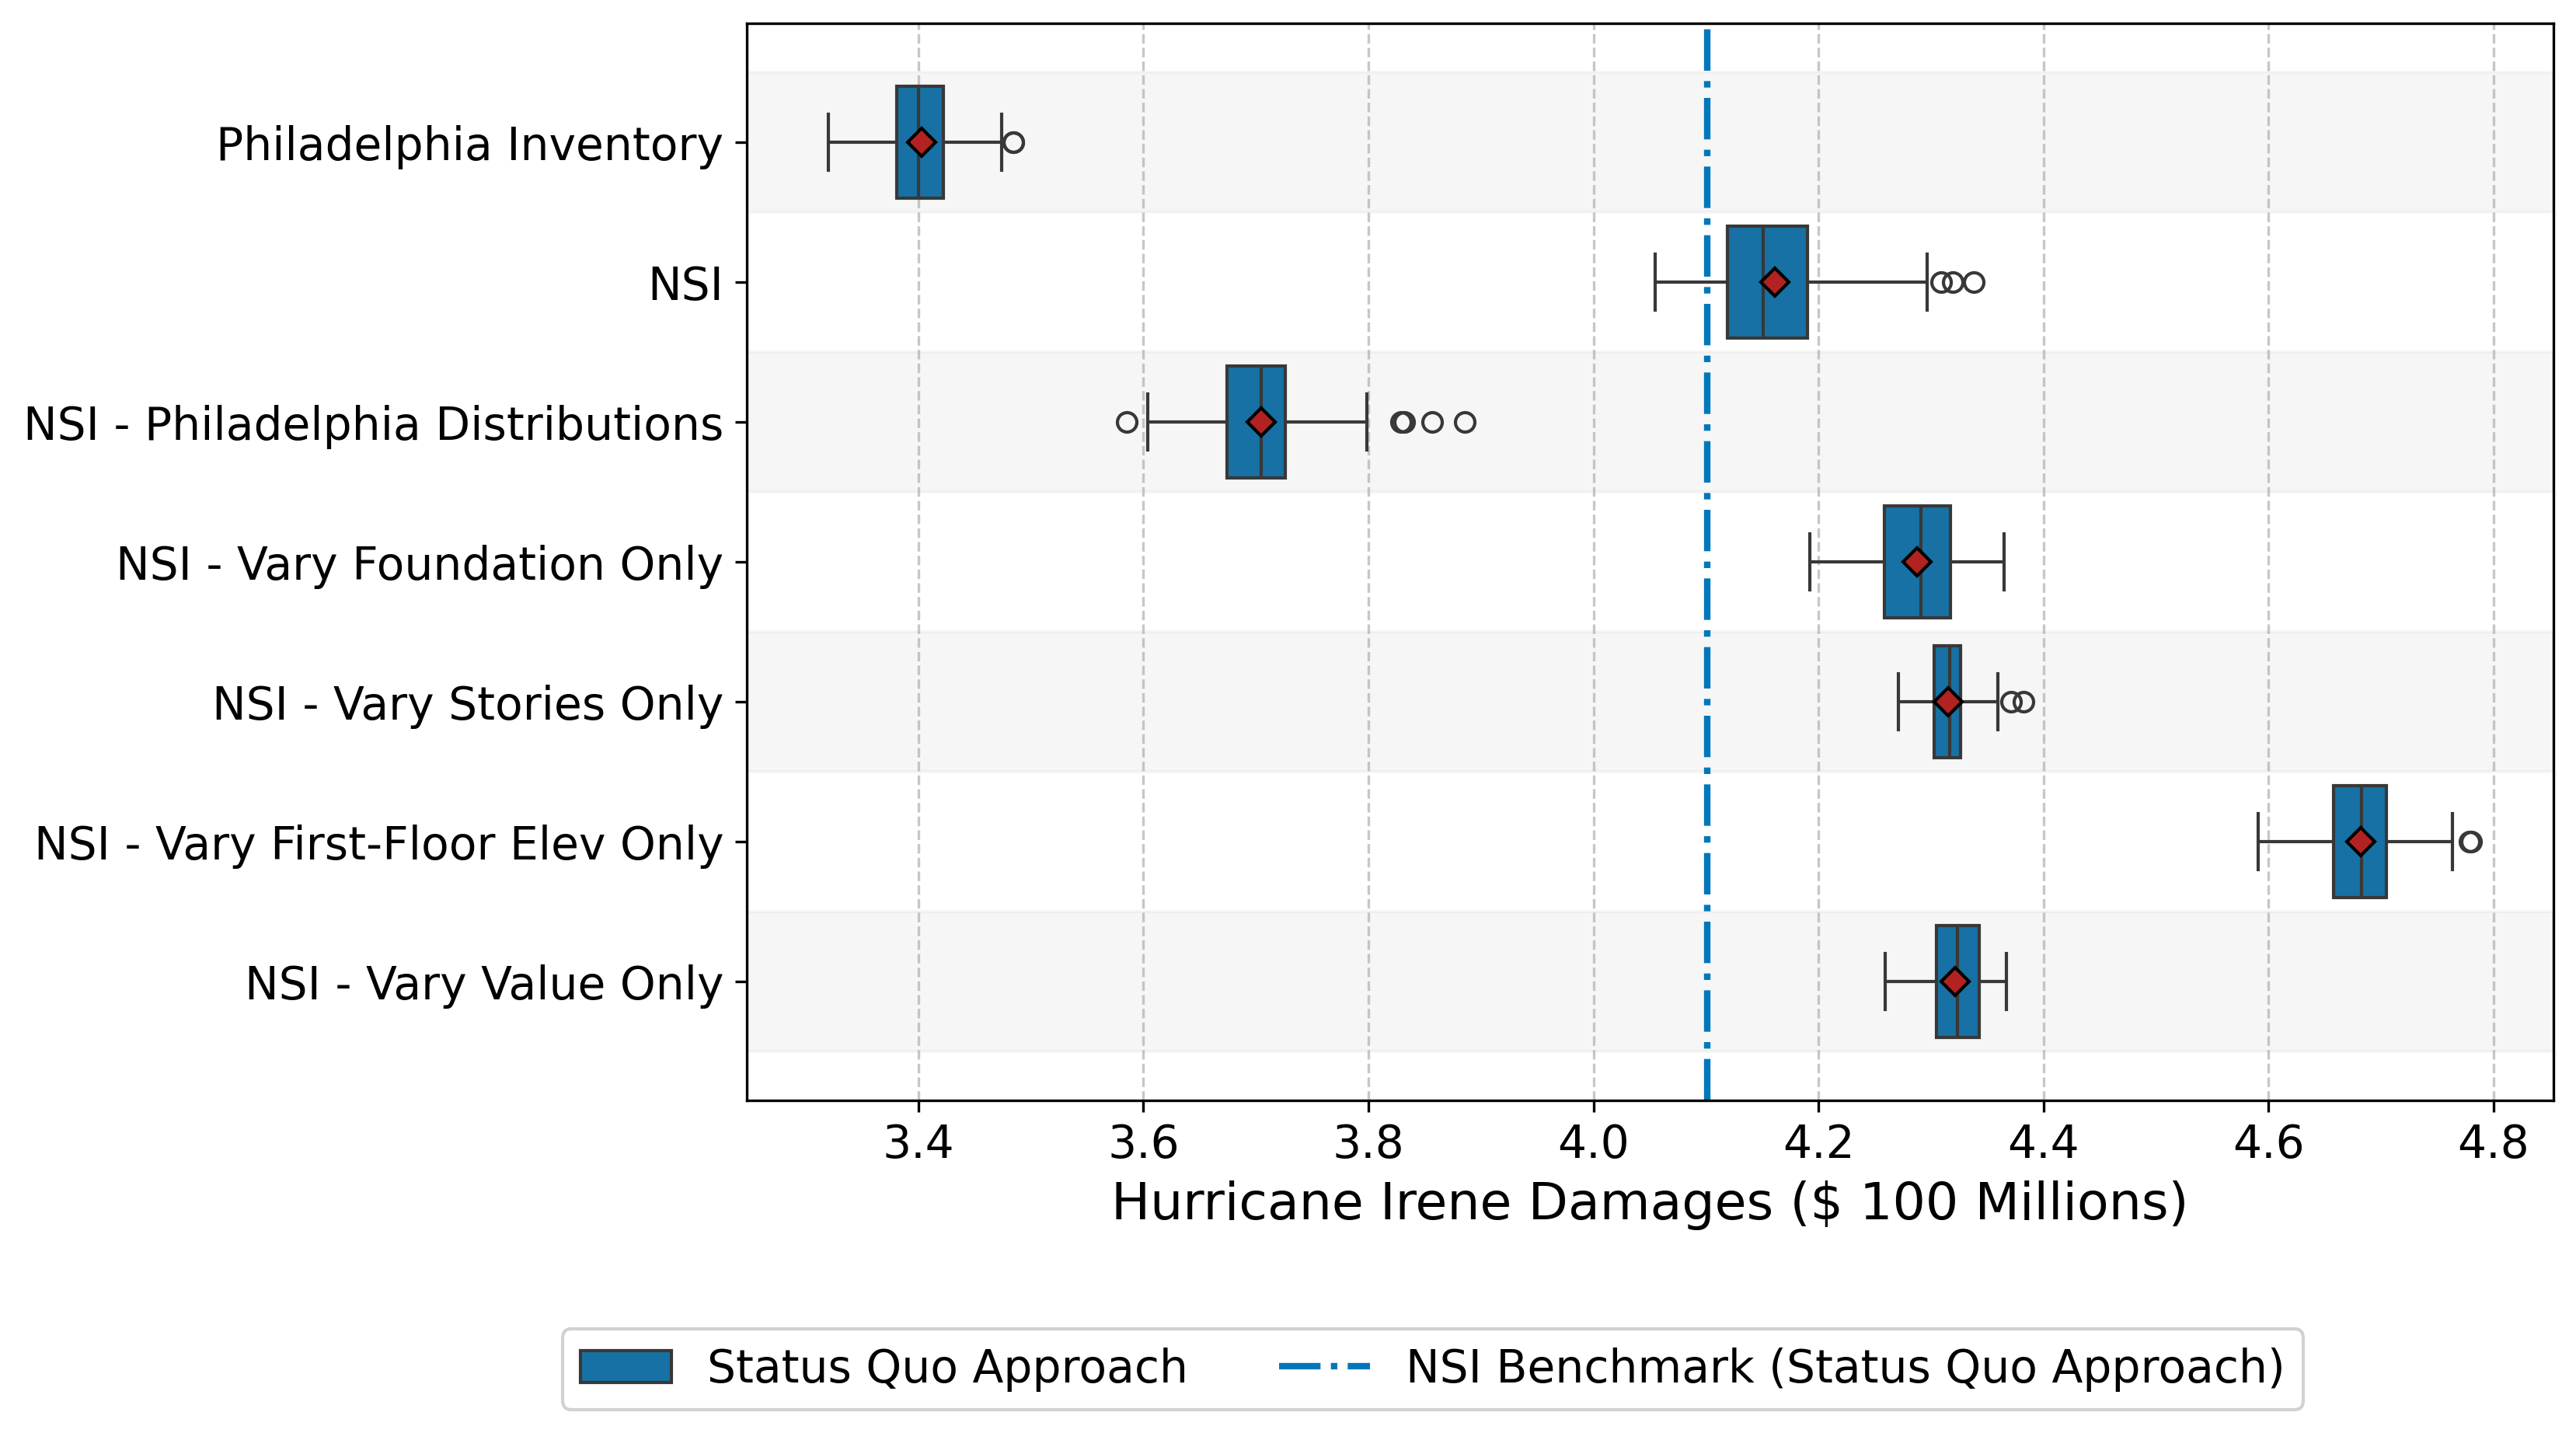

In [381]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns

# Process results for plotting
processed_data = []
for name, result in results.items():
    model_name, adj_name = name.split(':', 1)
    
    if adj_name == 'no_adj':
        # Calculate total loss per sow
        loss = result.groupby('sow_ind')['naccs_loss_025'].sum()/1e8
        
        # Prepare for boxplot
        df = loss.reset_index()
        df['Structure Data'] = model_configs[model_name]['label']
        df['Basement Adjustment'] = base_configs[adj_name]['label']
        processed_data.append(df)

# Combine all data for boxplot
combined_data = pd.concat(processed_data, axis=0)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Create boxplot with structure data on y-axis and hue for basement adjustment
sns.boxplot(
    ax=ax,
    data=combined_data,
    y='Structure Data',
    x='naccs_loss_025',
    hue='Basement Adjustment',
    showmeans=True,
    meanprops={'markerfacecolor': 'firebrick', 'markeredgecolor': 'black', 'marker': 'D'},
    palette=[base_configs['no_adj']['color'], base_configs['with_adj']['color']]
)

# Add benchmark lines with matching colors
for run_title, base_config in base_configs.items():
    if 'no_adj' in run_title:
        ax.axvline(
            benchmarks[run_title + '_sum'], 
            color=base_config['color'], 
            linestyle='dashed' if 'RES3A' in run_title else 'dashdot', 
            linewidth=2, 
            label=f"NSI Benchmark ({base_config['label']})"
        )

# Format plot
ax.set_xlabel('Hurricane Irene Damages ($ 100 Millions)', size=16)
ax.set_ylabel('')  # No y-axis label needed
ax.tick_params(labelsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Customize legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles, 
    labels=labels,
    fontsize=14,
    bbox_to_anchor=(.38, -.25),
    loc='center',
    frameon=True,
    framealpha=0.9,
    ncols=2,
)

# Add a background color to alternate rows for better visual separation
num_categories = len(combined_data['Structure Data'].unique())
for i in range(num_categories):
    if i % 2 == 0:  # Every other row
        ax.axhspan(i-0.5, i+0.5, color='lightgray', alpha=0.2, zorder=0)

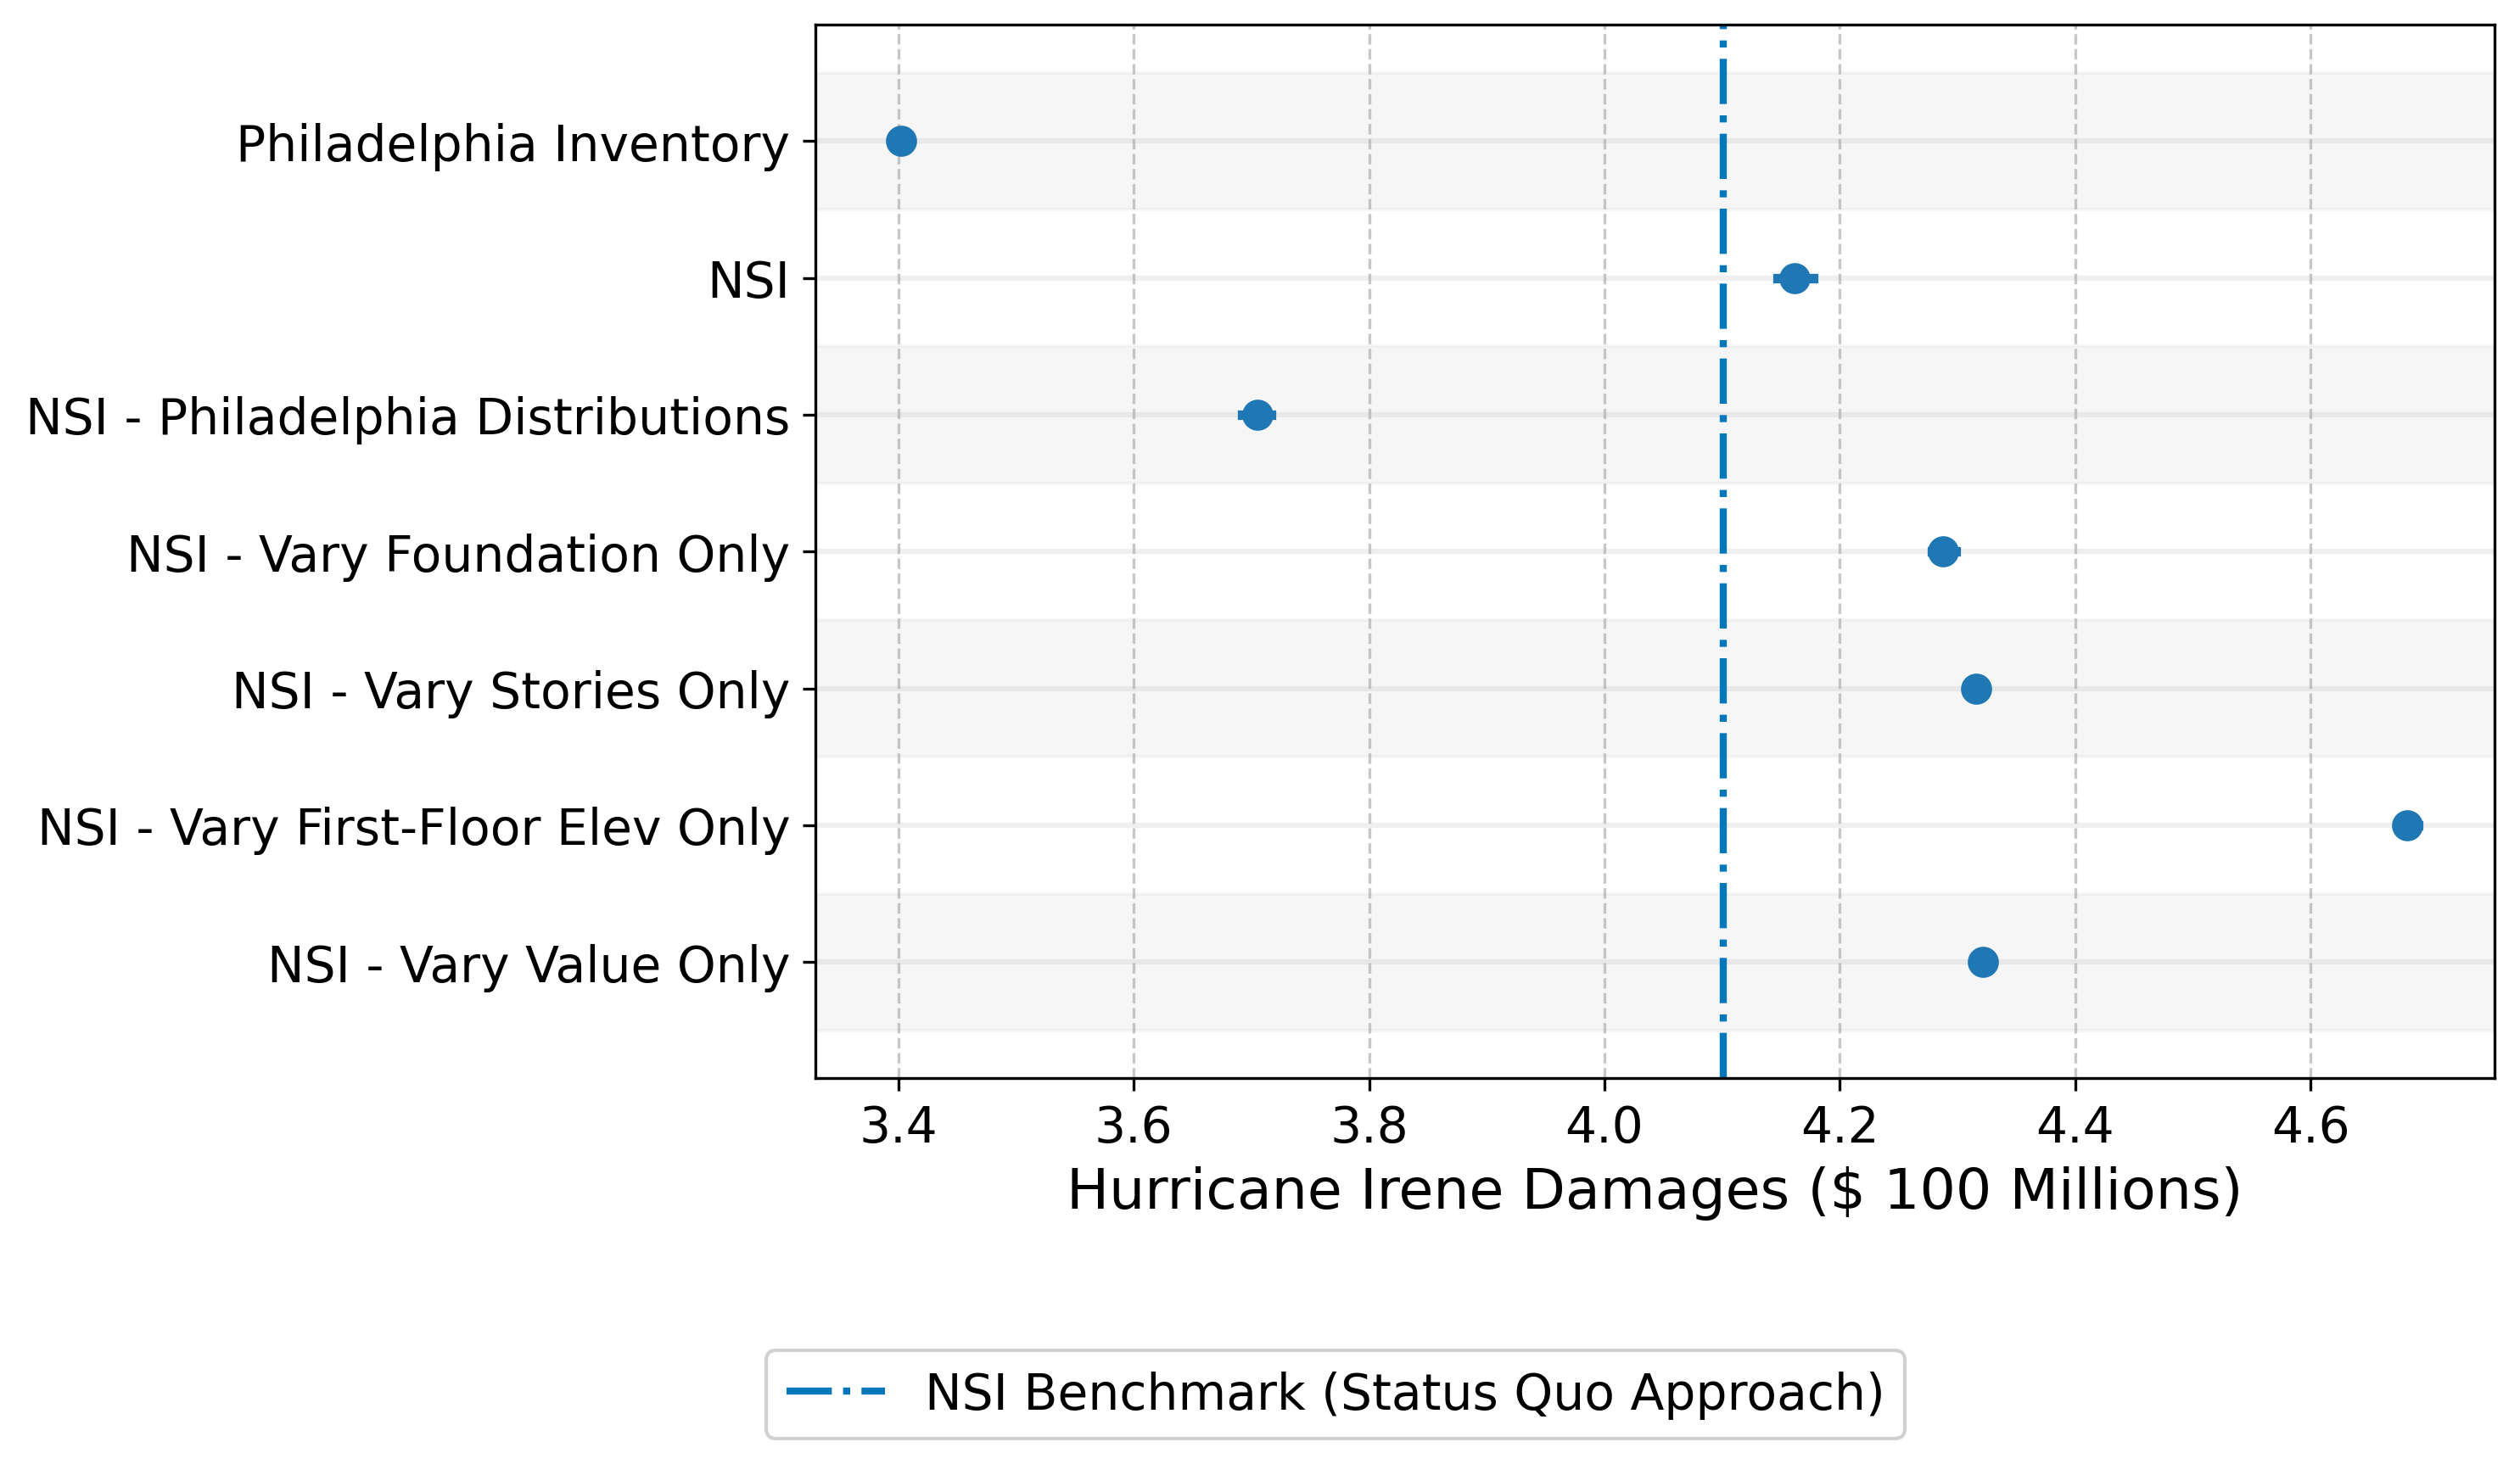

In [387]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Process results for plotting
processed_data = []
for name, result in results.items():
    model_name, adj_name = name.split(':', 1)
    
    if adj_name == 'no_adj':

        # Calculate total loss per sow
        loss = result.groupby('sow_ind')['naccs_loss_025'].sum()/1e8
        
        # Prepare for pointplot
        for value in loss:
            processed_data.append({
                'Structure Data': model_configs[model_name]['label'],
                # 'Basement Adjustment': base_configs[adj_name]['label'],
                'Loss': value
            })

# Convert to DataFrame
plot_data = pd.DataFrame(processed_data)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Create pointplot with means and std error
sns.pointplot(
    ax=ax,
    data=plot_data,
    y='Structure Data',
    x='Loss',
    # hue='Basement Adjustment',
    # palette=[base_configs['no_adj']['color'], base_configs['with_adj']['color']],
    # markers=['o', 's'],
    # markersize=10,
    estimator='mean',
    errorbar=('ci', 99),
    # dodge=.5,
    ls=''
)

# Add benchmark lines with matching colors
for run_title, base_config in base_configs.items():
    if 'no_adj' in run_title:
        ax.axvline(
            benchmarks[run_title + '_sum'],
            color=base_config['color'],
            linestyle='dashed' if 'RES3A' in run_title else 'dashdot',
            linewidth=2,
            label=f"NSI Benchmark ({base_config['label']})"
        )

# Format plot
ax.set_xlabel('Hurricane Irene Damages ($ 100 Millions)', size=16)
ax.set_ylabel('') 
ax.tick_params(axis='both', labelsize=14)

# Add grid lines
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.grid(axis='y', linestyle='-', linewidth=1.5, alpha=0.2)

# Add a background color to alternate rows for better visual separation
num_categories = len(plot_data['Structure Data'].unique())
for i in range(num_categories):
    if i % 2 == 0:
        ax.axhspan(i-0.5, i+0.5, color='lightgray', alpha=0.2, zorder=0)

# Customize legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    fontsize=14,
    loc='center',
    frameon=True,
    framealpha=0.9,
    ncol=2,
    bbox_to_anchor=(.31, -.3)
)

plt.tight_layout()

In [416]:
temp = all_results['original']['phil:no_adj']
temp_w_refs = temp.merge(phil_refs, on='bfid')
temp_gb = temp_w_refs.groupby(['sow_ind', 'tract_id']).agg({'naccs_loss_025': 'sum'}).reset_index()
main_phil_loss = temp_gb.groupby('tract_id')['naccs_loss_025'].mean()

tract_vals = phil_inv_ens.groupby('tract_id').agg({'val_struct': ['median', 'size']})
tract_vals = tract_vals.reset_index()
tract_vals.columns = ['tract_id', 'median_val', 'n_prop']
tract_vals = tract_vals.set_index('tract_id')

main_phil = pd.DataFrame(data=dict(naccs_loss_025=main_phil_loss,
                                   median_val=tract_vals['median_val'],
                                   n_prop=tract_vals['n_prop']))
main_phil = main_phil[main_phil['naccs_loss_025'].notnull()]

In [418]:
temp2 = all_benchmarks['original']['no_adj']
temp2_w_refs = temp2.merge(nsi_refs, on='fd_id')
temp2_gb = temp2_w_refs.groupby(['tract_id'])['naccs_loss_025'].sum().reset_index()

In [419]:
comp = temp2_gb.merge(main_phil.reset_index(),
                      on='tract_id',
                      suffixes=['_nsi', '_phil']).fillna(0)

In [420]:
tract_ref = gpd.read_file(join(REF_DIR_I, FIPS, 'tract.gpkg'))[['GEOID', 'geometry']]
comp_geo = tract_ref.merge(comp, left_on='GEOID', right_on='tract_id')

/var/folders/d2/g0h08s551zb2hz_ws2g4ggh400hbd0/T/ipykernel_2010/1704265063.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/f006dwr/miniforge3/envs/nsi_fit/lib/python3.12/site-packages/matplotlib/transforms.py:2654: RuntimeWarning: invalid value encountered in scalar multiply
  self._mtx = np.array([[x_scale, 0.0    , (-inl*x_scale)],
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite 

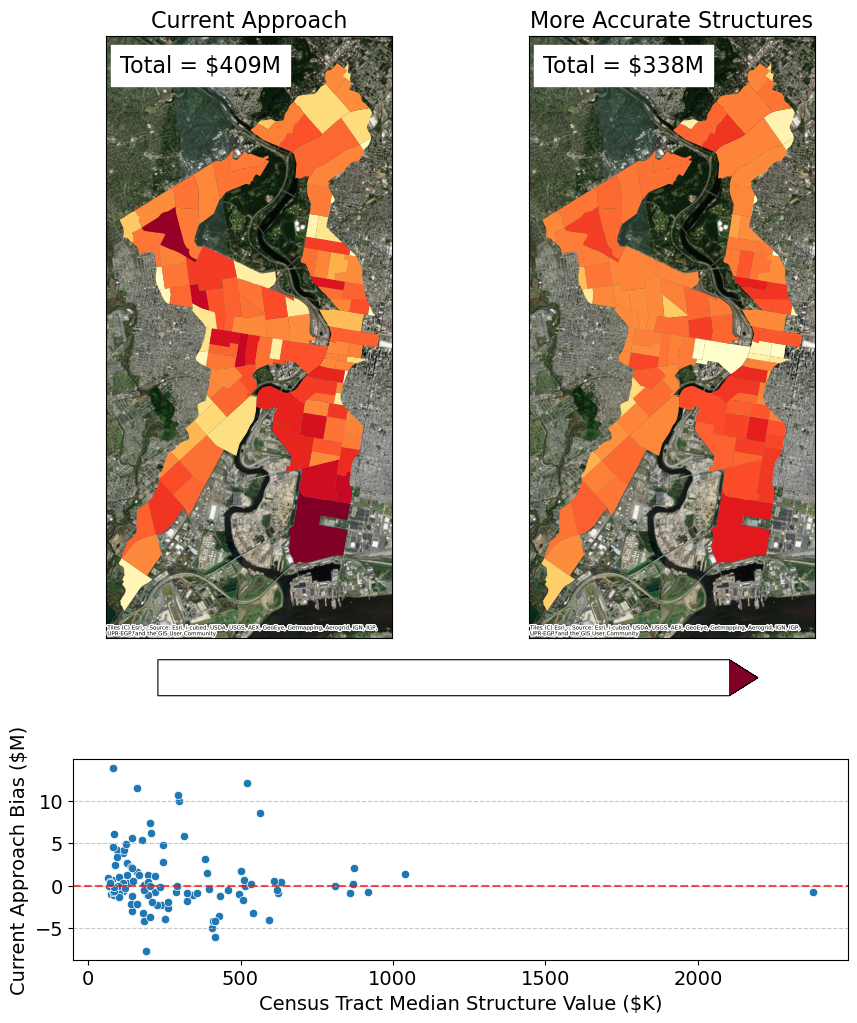

In [421]:
import contextily as cx
from matplotlib import ticker
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
import seaborn as sns

fig = plt.figure(figsize=(10, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=.3)

# Create axes for maps and boxplot
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])

comp_plot = comp_geo.to_crs(epsg=3857)

cmap = 'YlOrRd'

comp_plot['nsi_loss'] = comp_plot['naccs_loss_025_nsi']/1e6
comp_plot['phil_loss'] = comp_plot['naccs_loss_025_phil']/1e6

total_nsi_loss = comp_plot['nsi_loss'].sum()
total_phil_loss = comp_plot['phil_loss'].sum()

vmin = min(comp_plot['nsi_loss'].min(), comp_plot['phil_loss'].min())
vmax = max(comp_plot['nsi_loss'].max(), comp_plot['phil_loss'].max())
vcenter=1

comp_plot.plot(ax=ax0, column='nsi_loss', cmap=cmap,
               norm=colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax))
comp_plot.plot(ax=ax1, column='phil_loss', cmap=cmap,
               norm=colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax))

ax0.annotate('Total = ${}M'.format(int(total_nsi_loss)),
             xy=(.05, .94),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=16
             )
ax1.annotate('Total = ${}M'.format(int(total_phil_loss)),
             xy=(.05, .94),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=16
             )

cx.add_basemap(ax0,
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)

cx.add_basemap(ax1,
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)

ax0.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    labelbottom=False,
    labelleft=False,
)
ax1.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    labelbottom=False,
    labelleft=False,
)

# Add titles
ax0.set_title("Current Approach", fontsize=16)
ax1.set_title("More Accurate Structures", fontsize=16)

# Add continuous legends
cax = fig.add_axes([0.21, 0.33, 0.6, 0.03])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
)
sm._A = []
cbr = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal",
    extend='max'
)
cbr.ax.tick_params(labelsize=14)
cbr.set_ticks([0, .5, 1, 5, 10, 15])
cbr.set_label("Structure Damage in Census Tract ($ M)", size=14)

# Add loss bias in subplot below
comp_plot['val_thou'] = comp_plot['median_val']/1e3
comp_plot['bias'] = comp_plot['nsi_loss'] - comp_plot['phil_loss']

sns.scatterplot(
    ax=ax2,
    x='val_thou',
    y='bias',
    data=comp_plot
)

# Add a horizontal line at y=0 to show no difference
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7)

# Format 
ax2.set_xlabel('Census Tract Median Structure Value ($K)', fontsize=14)
ax2.set_ylabel('Current Approach Bias ($M)', fontsize=14)
ax2.tick_params(labelsize=14)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()

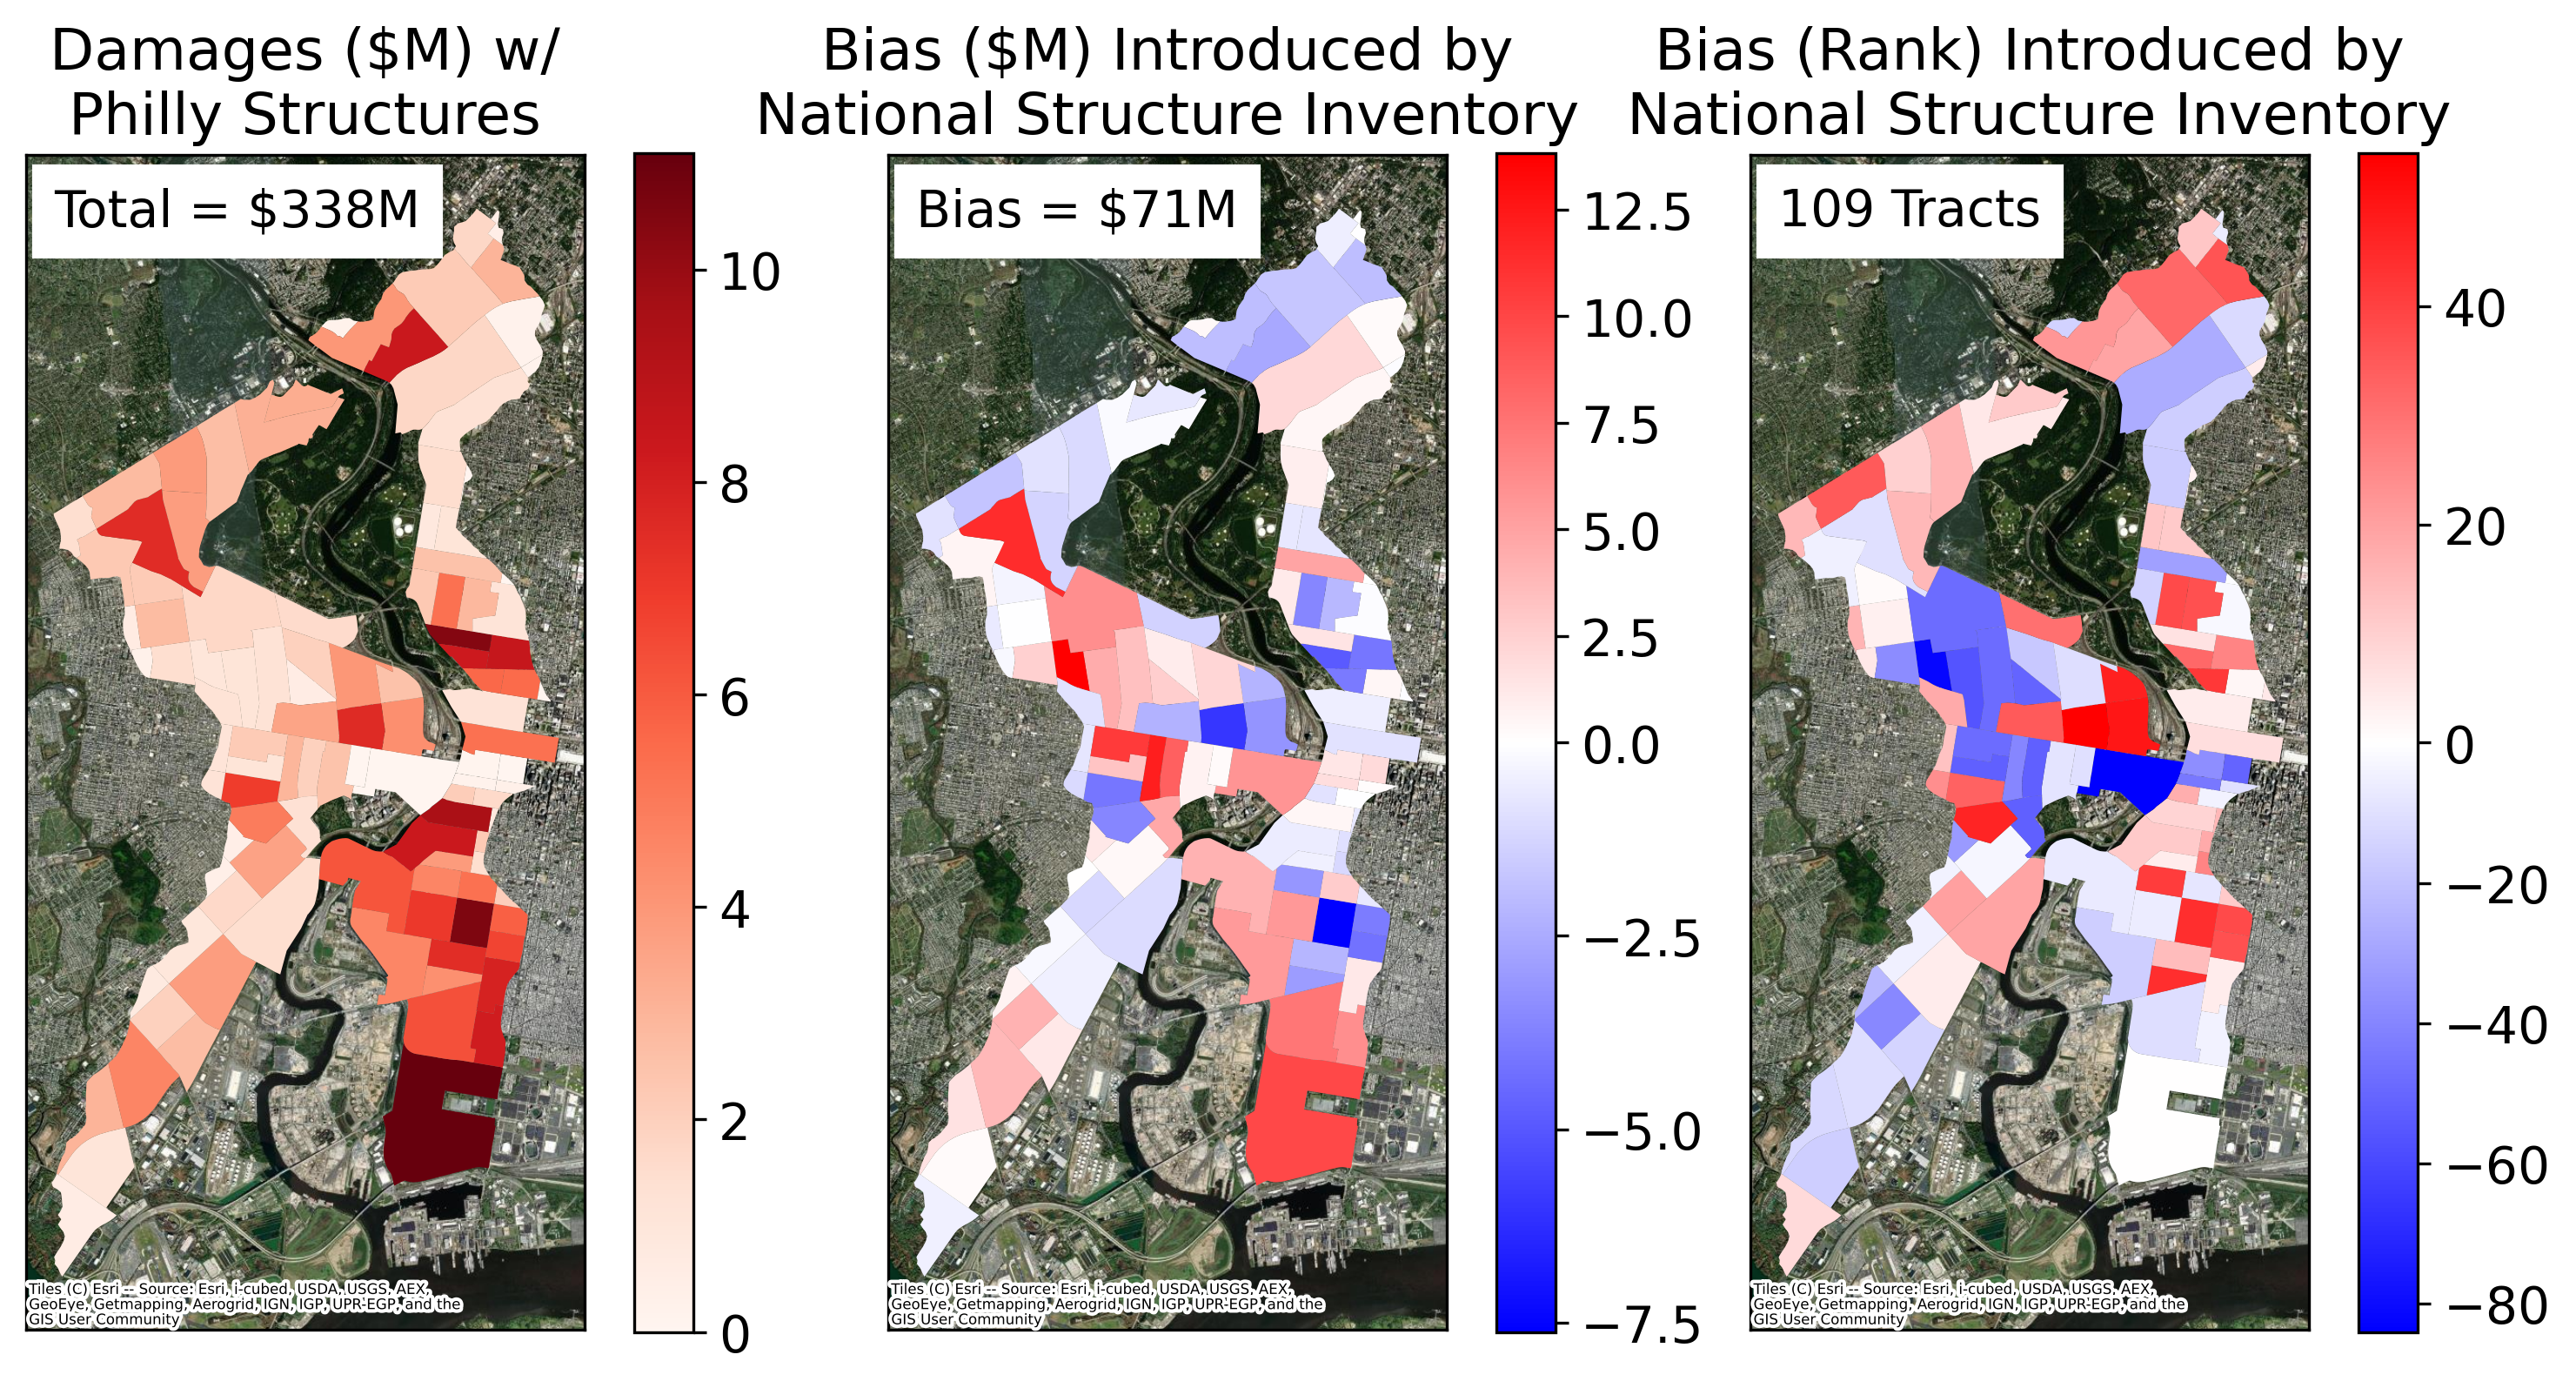

In [395]:
import contextily as cx
from matplotlib import ticker
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6), ncols=3, dpi=300)

comp_plot = comp_geo.to_crs(epsg=3857)

cmap = 'YlOrRd'

comp_plot['nsi_loss'] = comp_plot['naccs_loss_025_nsi']/1e6
comp_plot['phil_loss'] = comp_plot['naccs_loss_025_phil']/1e6

comp_plot['dam_bias'] = comp_plot['nsi_loss'] - comp_plot['phil_loss']
comp_plot['rank_bias'] = (comp_plot['nsi_loss'].rank(ascending=False) -
                          comp_plot['phil_loss'].rank(ascending=False))

total_nsi_loss = comp_plot['nsi_loss'].sum()
total_phil_loss = comp_plot['phil_loss'].sum()

vmin = min(comp_plot['nsi_loss'].min(), comp_plot['phil_loss'].min())
vmax = max(comp_plot['nsi_loss'].max(), comp_plot['phil_loss'].max())
vcenter=1

comp_plot.plot(ax=ax[0], column='phil_loss', cmap='Reds',
               legend=True,
               legend_kwds={'pad': .07,
                           'shrink': .8},
               vmin=0, vmax=comp_plot['phil_loss'].max())
comp_plot.plot(ax=ax[1], column='dam_bias', cmap='bwr',
               legend=True,
               legend_kwds={'pad': .07,
                           'shrink': .8},
               norm=colors.TwoSlopeNorm(vmin=comp_plot['dam_bias'].min(),
                                        vcenter=0,
                                        vmax=comp_plot['dam_bias'].max()))
comp_plot.plot(ax=ax[2], column='rank_bias', cmap='bwr',
               legend=True,
               legend_kwds={'pad': .07,
                           'shrink': .8},
               norm=colors.TwoSlopeNorm(vmin=comp_plot['rank_bias'].min(),
                                        vcenter=0,
                                        vmax=comp_plot['rank_bias'].max()))

cx.add_basemap(ax[0],
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)

cx.add_basemap(ax[1],
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)

cx.add_basemap(ax[2],
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)

for i in range(3):
    ax[i].tick_params(
        axis="both",
        which="both",
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False,
    )

# Add titles
ax[0].set_title("Damages ($M) w/\nPhilly Structures", fontsize=16)
ax[1].set_title("Bias ($M) Introduced by\nNational Structure Inventory", fontsize=16)
ax[2].set_title("Bias (Rank) Introduced by\n National Structure Inventory", fontsize=16)

# Add annotations
ax[0].annotate('Total = ${}M'.format(int(total_phil_loss)),
             xy=(.05, .94),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=14
             )

ax[1].annotate('Bias = ${}M'.format(int(total_nsi_loss - total_phil_loss)),
             xy=(.05, .94),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=14
             )

ax[2].annotate('{} Tracts'.format(len(comp_plot)),
             xy=(.05, .94),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=14
             )

# Update colorbar tick label size
for ax in fig.axes:
    if ax._axes.get_label() == '<colorbar>':
        ax.tick_params(labelsize='14')

fig.tight_layout()

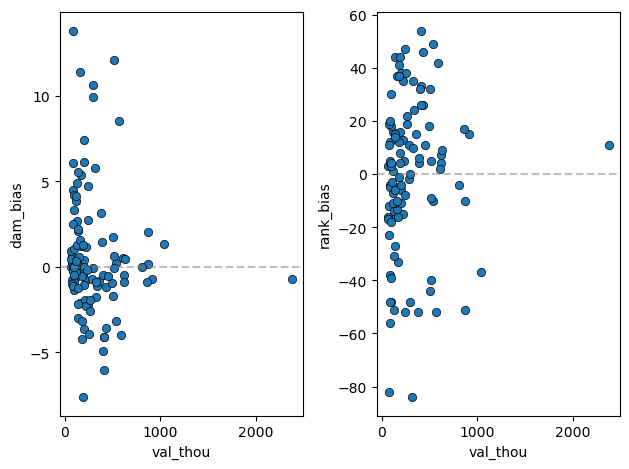

In [396]:
fig, ax = plt.subplots(ncols=2)
comp_plot['val_thou'] = comp_plot['median_val']/1e3
comp_plot['phil_rank'] = comp_plot['phil_loss'].rank(ascending=False)

# Add a horizontal line at y=0 to show no difference
ax[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
sns.scatterplot(
    ax=ax[0],
    y='dam_bias',
    x='val_thou',
    edgecolor='black',
    data=comp_plot.sort_values('phil_loss', ascending=True)
)

ax[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
sns.scatterplot(
    ax=ax[1],
    y='rank_bias',
    x='val_thou',
    edgecolor='black',
    data=comp_plot.sort_values('phil_loss', ascending=True)
)

fig.tight_layout()

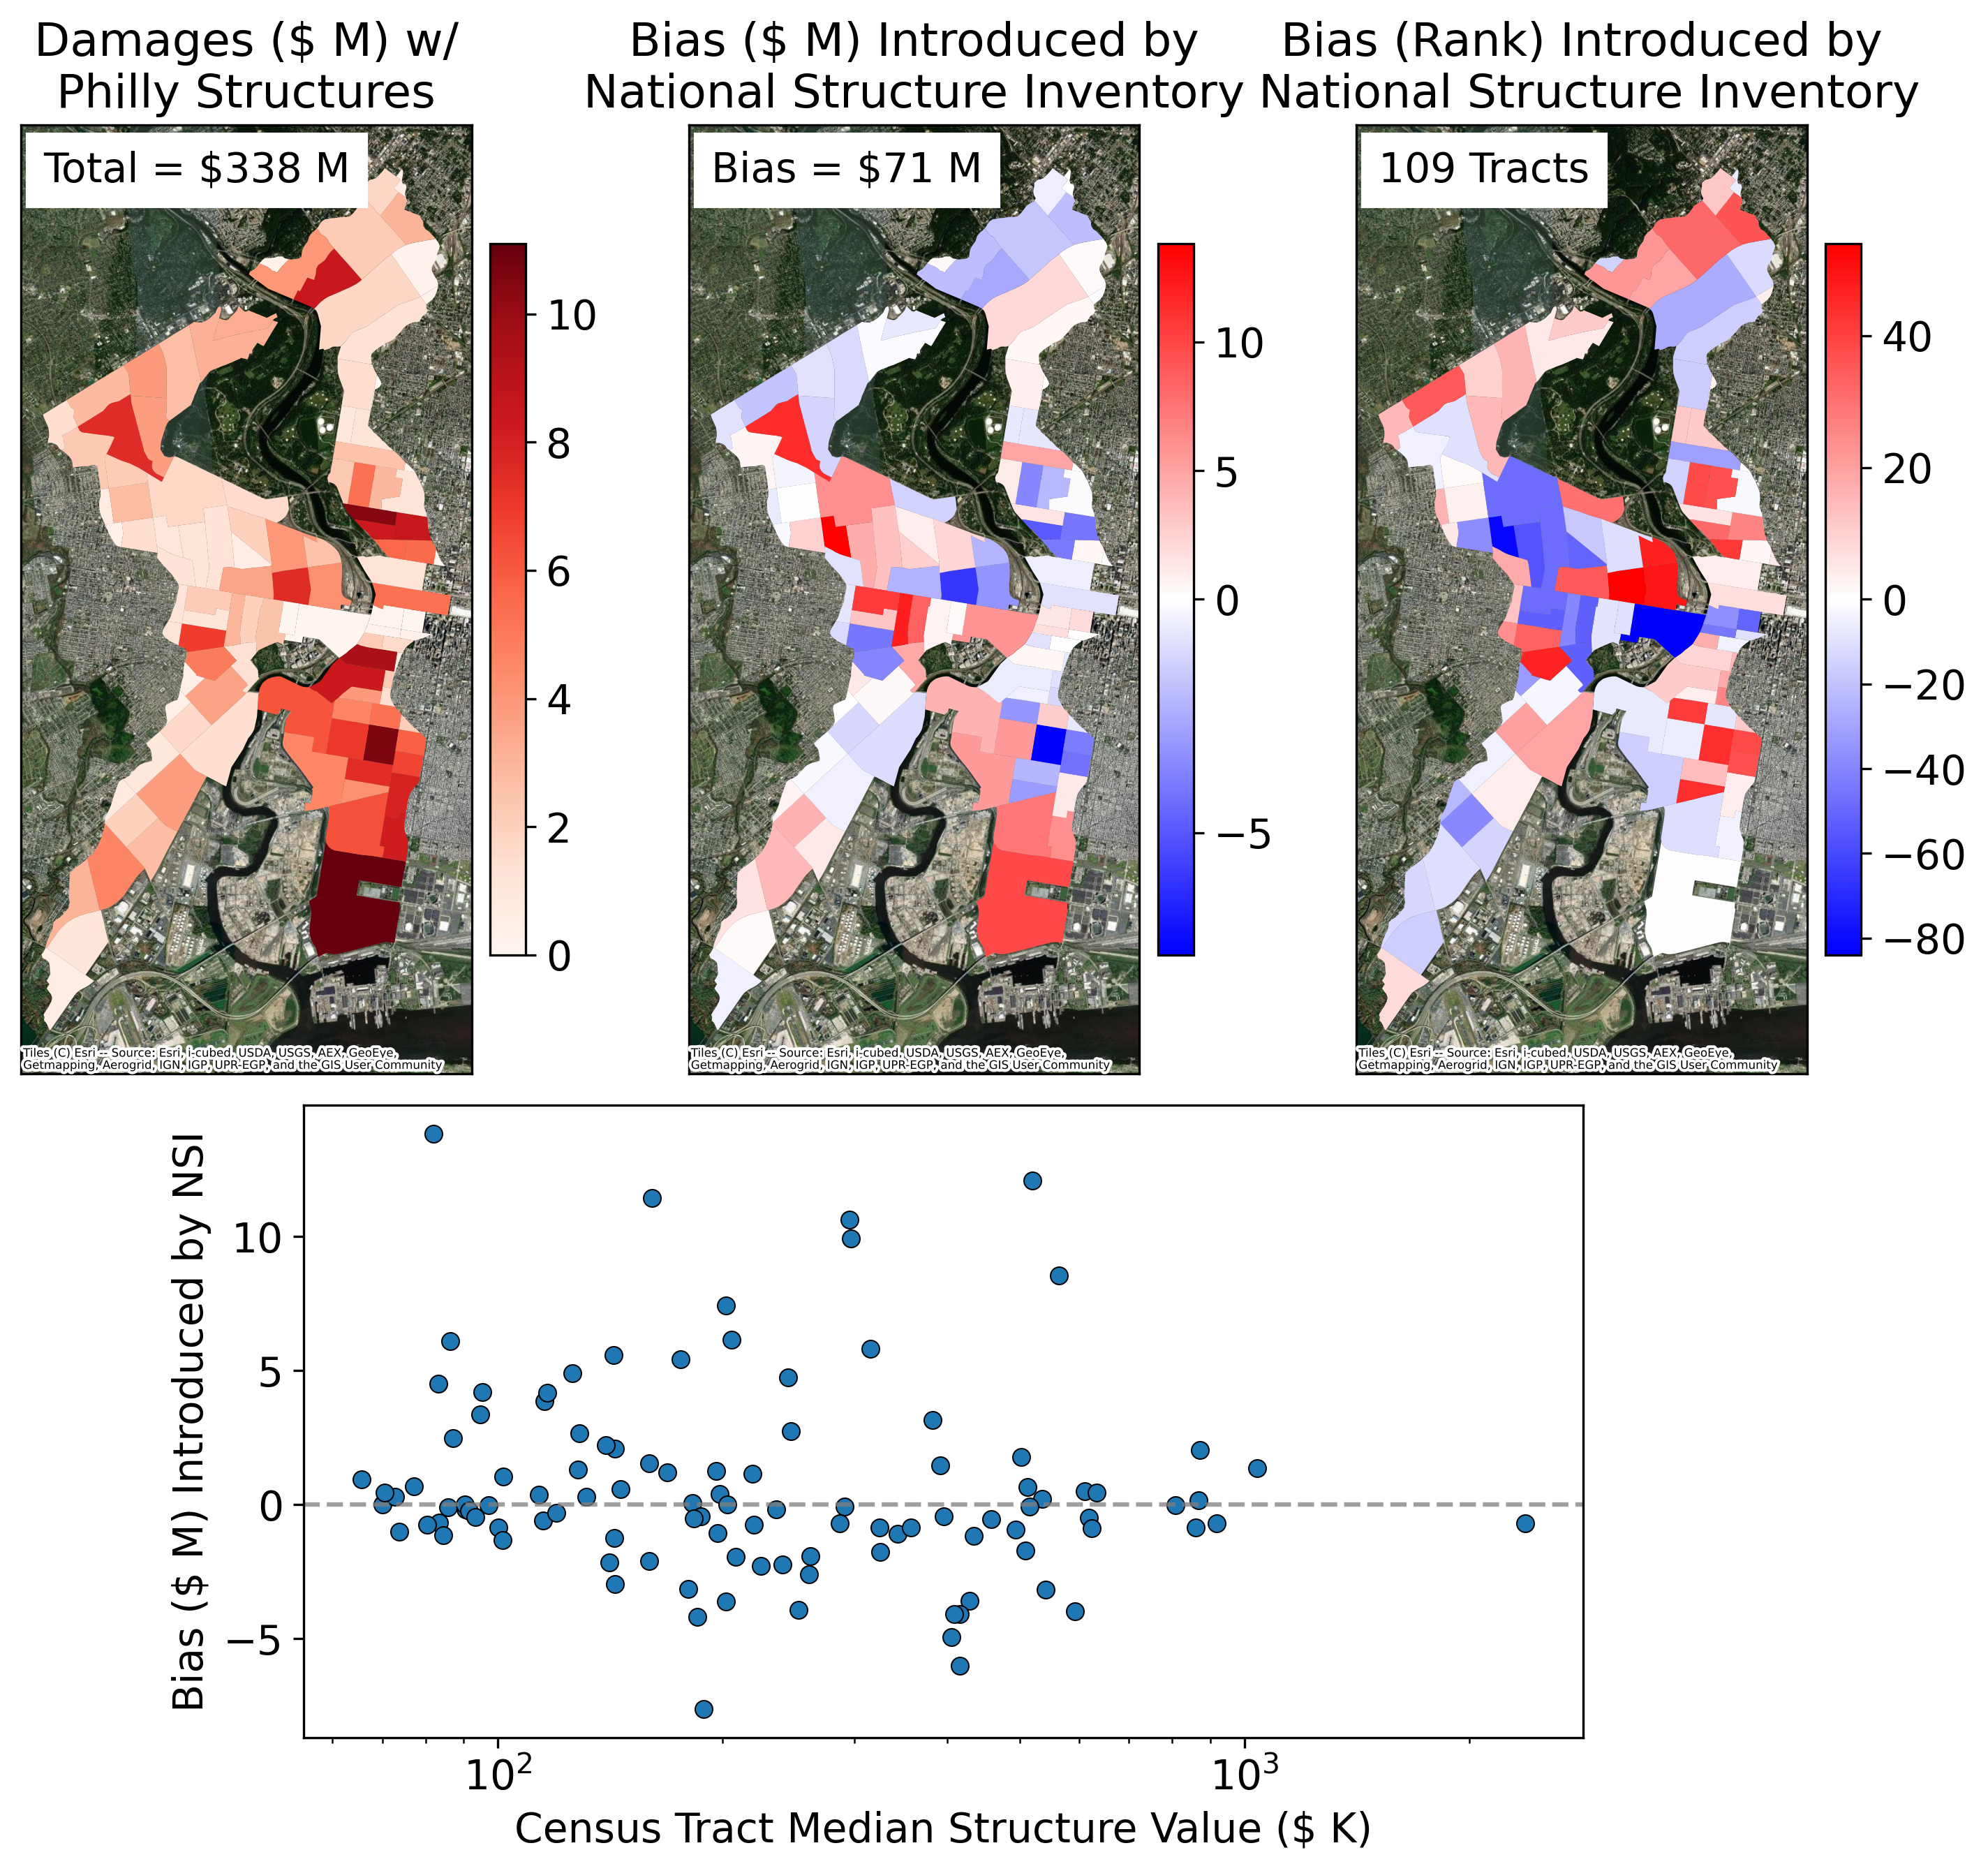

In [432]:
import contextily as cx
from matplotlib import ticker
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

# fig, ax = plt.subplots(figsize=(10, 6), ncols=3, dpi=300)

fig = plt.figure(figsize=(12, 10), dpi=300)
gs = gridspec.GridSpec(2, 6, height_ratios=[3, 2], hspace=.04)

# Create axes for maps and boxplot
ax0 = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[0, 2:4])
ax2 = fig.add_subplot(gs[0, 4:6])
ax3 = fig.add_subplot(gs[1, 1:5])

comp_plot = comp_geo.to_crs(epsg=3857)

cmap = 'YlOrRd'

comp_plot['nsi_loss'] = comp_plot['naccs_loss_025_nsi']/1e6
comp_plot['phil_loss'] = comp_plot['naccs_loss_025_phil']/1e6

comp_plot['dam_bias'] = comp_plot['nsi_loss'] - comp_plot['phil_loss']
comp_plot['rank_bias'] = (comp_plot['nsi_loss'].rank(ascending=False) -
                          comp_plot['phil_loss'].rank(ascending=False))

total_nsi_loss = comp_plot['nsi_loss'].sum()
total_phil_loss = comp_plot['phil_loss'].sum()

vmin = min(comp_plot['nsi_loss'].min(), comp_plot['phil_loss'].min())
vmax = max(comp_plot['nsi_loss'].max(), comp_plot['phil_loss'].max())
vcenter=1

comp_plot.plot(ax=ax0, column='phil_loss', cmap='Reds',
               legend=True,
               legend_kwds={'pad': .03,
                           'shrink': .75},
               vmin=0, vmax=comp_plot['phil_loss'].max())
comp_plot.plot(ax=ax1, column='dam_bias', cmap='bwr',
               legend=True,
               legend_kwds={'pad': .03,
                           'shrink': .75},
               norm=colors.TwoSlopeNorm(vmin=comp_plot['dam_bias'].min(),
                                        vcenter=0,
                                        vmax=comp_plot['dam_bias'].max()))
comp_plot.plot(ax=ax2, column='rank_bias', cmap='bwr',
               legend=True,
               legend_kwds={'pad': .03,
                           'shrink': .75},
               norm=colors.TwoSlopeNorm(vmin=comp_plot['rank_bias'].min(),
                                        vcenter=0,
                                        vmax=comp_plot['rank_bias'].max()))

cx.add_basemap(ax0,
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)

cx.add_basemap(ax1,
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)

cx.add_basemap(ax2,
               attribution_size=4,
               source=cx.providers.Esri.WorldImagery)


axes = [ax0, ax1, ax2]
for i in range(3):
    axes[i].tick_params(
        axis="both",
        which="both",
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False,
    )

# Add titles
axes[0].set_title("Damages ($ M) w/\nPhilly Structures", fontsize=16)
axes[1].set_title("Bias ($ M) Introduced by\nNational Structure Inventory", fontsize=16)
axes[2].set_title("Bias (Rank) Introduced by\n National Structure Inventory", fontsize=16)

# Add annotations
axes[0].annotate('Total = ${} M'.format(int(total_phil_loss)),
             xy=(.05, .94),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=14
             )

axes[1].annotate('Bias = ${} M'.format(int(total_nsi_loss - total_phil_loss)),
             xy=(.05, .94),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=14
             )

axes[2].annotate('{} Tracts'.format(len(comp_plot)),
             xy=(.05, .94),
             xycoords='axes fraction',
             color='black',
             backgroundcolor='white',
             size=14
             )

# Update colorbar tick label size
for ax in fig.axes:
    if ax._axes.get_label() == '<colorbar>':
        ax.tick_params(labelsize='14')

comp_plot['val_thou'] = comp_plot['median_val']/1e3
comp_plot['phil_rank'] = comp_plot['phil_loss'].rank(ascending=False)

# Add a horizontal line at y=0 to show no difference
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
sns.scatterplot(
    ax=ax3,
    y='dam_bias',
    x='val_thou',
    edgecolor='black',
    data=comp_plot.sort_values('phil_loss', ascending=True)
)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.set_xscale('log')

ax3.set_xlabel('Census Tract Median Structure Value ($ K)', fontsize=14)
ax3.set_ylabel('Bias ($ M) Introduced by NSI', fontsize=14)
ax3.tick_params(labelsize=14)

In [426]:
comp_plot.sort_values('median_val', ascending=False).head()

,GEOID,geometry,tract_id,naccs_loss_025_nsi,naccs_loss_025_phil,median_val,n_prop,nsi_loss,phil_loss,dam_bias,rank_bias,val_thou,phil_rank
93,42101012201,"MULTIPOLYGON (((-8372853.437 4866430.781, -837...",42101012201,2.560953e+06,3.253066e+06,2.376430e+06,31,2.560953,3.253066,-0.692114,11.0,2376.430236,39.0
35,42101000401,"MULTIPOLYGON (((-8369023.955 4859328.702, -836...",42101000401,1.460343e+06,1.085461e+05,1.040040e+06,8,1.460343,0.108546,1.351797,-37.0,1040.040000,103.0
27,42101001203,"MULTIPOLYGON (((-8368436.081 4858005.106, -836...",42101001203,8.963080e+04,7.865329e+05,9.180000e+05,62,0.089631,0.786533,-0.696902,15.0,918.000000,89.0
34,42101000404,"MULTIPOLYGON (((-8368260.306 4859058.303, -836...",42101000404,2.049570e+06,2.092291e+04,8.715200e+05,15,2.049570,0.020923,2.028647,-51.0,871.520000,106.0
31,42101000701,"MULTIPOLYGON (((-8368298.489 4858828.719, -836...",42101000701,4.884705e+05,3.419878e+05,8.681600e+05,17,0.488471,0.341988,0.146483,-10.0,868.160000,97.0


In [210]:
phil_inv_out[phil_inv_out['bfid'] == 80687]

,parcel_number,val_struct,bld_type,stories_n,bfid,ddf_stories,b_type,occ_type,geometry
94422,881111200,1.880424e+07,APTS,3,80687,2.0,NB,RES3,"MULTIPOLYGON (((-75.19481 39.95876, -75.19476 ..."
